# Cross-Dataset Evaluation
Model performance evaluation across different deepfake datasets and architectures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)

# Define models and datasets
models = ['3ch', '3ch_res', '6ch']
datasets = ['DF', 'F2F', 'FS', 'NT', 'FSfter', 'DFD']

print(f"Models: {models}")
print(f"Datasets: {datasets}")

Models: ['3ch', '3ch_res', '6ch']
Datasets: ['DF', 'F2F', 'FS', 'NT', 'FSfter', 'DFD']


In [2]:
# Load all cross-dataset probabilities
data_dict = {}

for model in models:
    data_dict[model] = {}
    for dataset in datasets:
        csv_path = f'../logs/cross_dataset_probabilities/{model}/{dataset}_probabilities.csv'
        try:
            data_dict[model][dataset] = pd.read_csv(csv_path)
            print(f"✓ Loaded {model}/{dataset}: {len(data_dict[model][dataset])} samples")
        except FileNotFoundError:
            print(f"✗ Not found: {csv_path}")

# Display sample data
print("\n" + "="*80)
print("Sample data (3ch/DF):")
print("="*80)
print(data_dict['3ch']['DF'].head())
print(f"\nShape: {data_dict['3ch']['DF'].shape}")
print(f"Columns: {data_dict['3ch']['DF'].columns.tolist()}")

✓ Loaded 3ch/DF: 4965 samples
✓ Loaded 3ch/F2F: 4975 samples
✓ Loaded 3ch/FS: 4511 samples
✓ Loaded 3ch/NT: 4513 samples
✓ Loaded 3ch/FSfter: 4973 samples
✓ Loaded 3ch/DFD: 4980 samples
✓ Loaded 3ch_res/DF: 4965 samples
✓ Loaded 3ch_res/F2F: 4975 samples
✓ Loaded 3ch_res/FS: 4511 samples
✓ Loaded 3ch_res/NT: 4513 samples
✓ Loaded 3ch_res/FSfter: 4973 samples
✓ Loaded 3ch_res/DFD: 4980 samples
✓ Loaded 6ch/DF: 4965 samples
✓ Loaded 6ch/F2F: 4975 samples
✓ Loaded 6ch/FS: 4511 samples
✓ Loaded 6ch/NT: 4513 samples
✓ Loaded 6ch/FSfter: 4973 samples
✓ Loaded 6ch/DFD: 4980 samples

Sample data (3ch/DF):
   Sample_ID  Real_Probability  Synthesis_Probability Predicted_Class  \
0          0          0.999997               0.000003            Real   
1          1          0.999999               0.000001            Real   
2          2          0.999992               0.000008            Real   
3          3          0.999971               0.000029            Real   
4          4          0.999969

In [3]:
# Calculate metrics for all combinations
metrics_dict = {}
curves_dict = {}

for model in models:
    metrics_dict[model] = {}
    curves_dict[model] = {}
    
    for dataset in datasets:
        df_data = data_dict[model][dataset]
        
        # Create binary labels: 1 for Synthesis, 0 for Real
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        
        # Calculate ROC curve metrics
        fpr, tpr, _ = roc_curve(y_true, y_scores)
        roc_auc = auc(fpr, tpr)
        
        # Calculate Precision-Recall curve metrics
        precision, recall, _ = precision_recall_curve(y_true, y_scores)
        pr_auc = auc(recall, precision)
        
        # Calculate confusion matrix metrics
        cm = confusion_matrix(y_true, (y_scores > 0.5).astype(int))
        tn, fp, fn, tp = cm.ravel()
        
        # Calculate metrics
        accuracy = (tp + tn) / (tp + tn + fp + fn)
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision_metric = tp / (tp + fp) if (tp + fp) > 0 else 0
        
        metrics_dict[model][dataset] = {
            'roc_auc': roc_auc,
            'pr_auc': pr_auc,
            'accuracy': accuracy,
            'sensitivity': sensitivity,
            'specificity': specificity,
            'precision': precision_metric,
            'tp': tp,
            'tn': tn,
            'fp': fp,
            'fn': fn,
            'cm': cm
        }
        
        curves_dict[model][dataset] = {
            'fpr': fpr,
            'tpr': tpr,
            'precision': precision,
            'recall': recall
        }

print("Metrics calculation completed for all model-dataset combinations")

Metrics calculation completed for all model-dataset combinations


In [4]:
# Create performance comparison table
print("\n" + "="*120)
print("PERFORMANCE COMPARISON TABLE - All Models and Datasets")
print("="*120)

# Create a DataFrame for better visualization
results = []
for model in models:
    for dataset in datasets:
        m = metrics_dict[model][dataset]
        results.append({
            'Model': model,
            'Dataset': dataset,
            'ROC AUC': m['roc_auc'],
            'PR AUC': m['pr_auc'],
            'Accuracy': m['accuracy'],
            'Sensitivity': m['sensitivity'],
            'Specificity': m['specificity'],
            'Precision': m['precision']
        })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))
print("="*120)

# Summary by model
print("\n" + "="*80)
print("SUMMARY BY MODEL (Average across all datasets)")
print("="*80)
for model in models:
    avg_roc_auc = np.mean([metrics_dict[model][ds]['roc_auc'] for ds in datasets])
    avg_pr_auc = np.mean([metrics_dict[model][ds]['pr_auc'] for ds in datasets])
    avg_accuracy = np.mean([metrics_dict[model][ds]['accuracy'] for ds in datasets])
    print(f"{model}: ROC AUC={avg_roc_auc:.4f}, PR AUC={avg_pr_auc:.4f}, Accuracy={avg_accuracy:.4f}")
print("="*80)


PERFORMANCE COMPARISON TABLE - All Models and Datasets
  Model Dataset  ROC AUC   PR AUC  Accuracy  Sensitivity  Specificity  Precision
    3ch      DF 0.773634 0.772360  0.562538     0.137667     0.985531   0.904509
    3ch     F2F 0.620219 0.595623  0.506131     0.026538     0.985531   0.647059
    3ch      FS 0.489023 0.451116  0.549102     0.013347     0.984727   0.415385
    3ch      NT 0.579951 0.502451  0.551296     0.017778     0.985531   0.500000
    3ch  FSfter 0.530444 0.523091  0.499095     0.013280     0.984325   0.458333
    3ch     DFD 0.865488 0.830396  0.548795     0.113563     0.984727   0.881620
3ch_res      DF 0.735423 0.722070  0.536959     0.085991     0.985932   0.858871
3ch_res     F2F 0.609383 0.599325  0.510955     0.035786     0.985932   0.717742
3ch_res      FS 0.528460 0.462507  0.550432     0.016807     0.984325   0.465753
3ch_res      NT 0.566737 0.503462  0.549967     0.015309     0.985129   0.455882
3ch_res  FSfter 0.565209 0.548677  0.502715     0.022

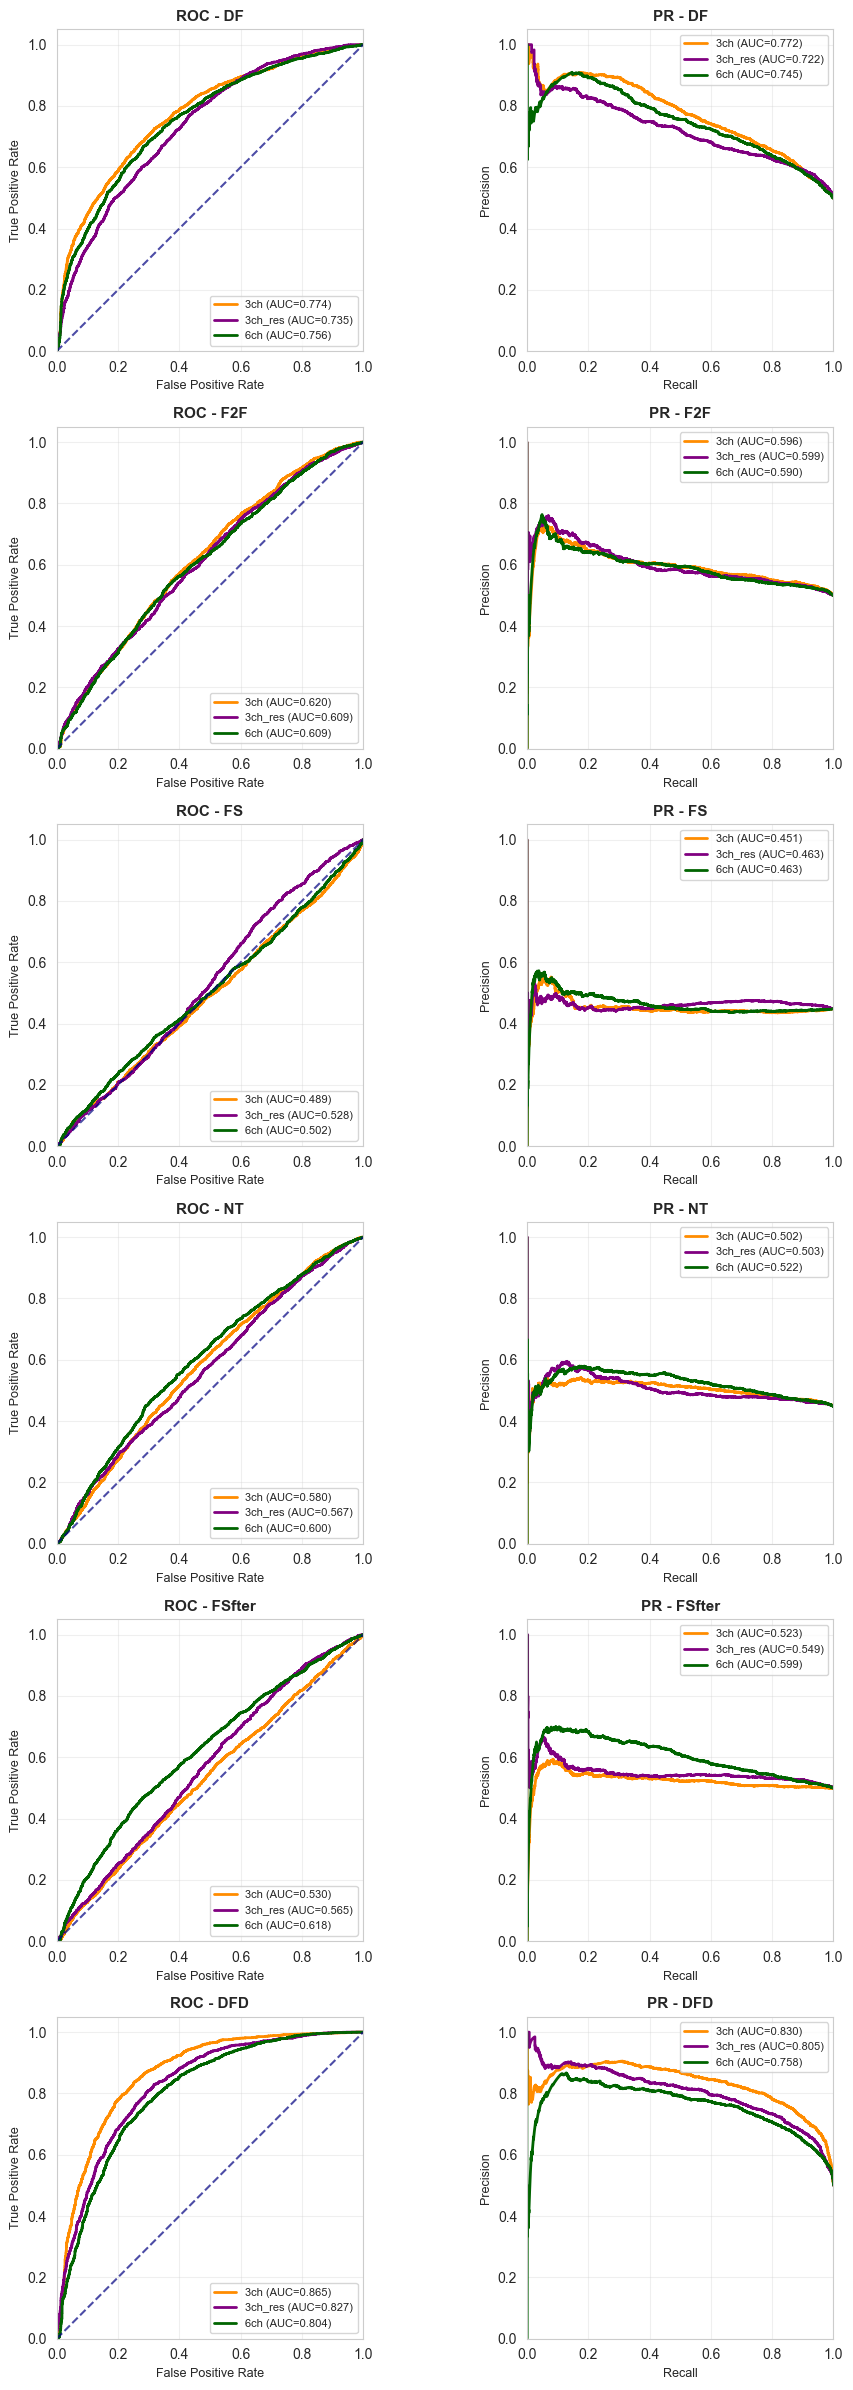

In [8]:
# Plot ROC and PR curves for each dataset - Model Comparison
colors = {'3ch': 'darkorange', '3ch_res': 'purple', '6ch': 'darkgreen'}

fig, axes = plt.subplots(6, 2, figsize=(10, 24))

for row_idx, dataset in enumerate(datasets):
    # ROC Curve (left column)
    for model in models:
        curves = curves_dict[model][dataset]
        auc_score = metrics_dict[model][dataset]['roc_auc']
        axes[row_idx, 0].plot(curves['fpr'], curves['tpr'], color=colors[model], lw=2,
                              label=f'{model} (AUC={auc_score:.3f})')
    
    axes[row_idx, 0].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', alpha=0.7)
    axes[row_idx, 0].set_xlim([0.0, 1.0])
    axes[row_idx, 0].set_ylim([0.0, 1.05])
    axes[row_idx, 0].set_xlabel('False Positive Rate', fontsize=9)
    axes[row_idx, 0].set_ylabel('True Positive Rate', fontsize=9)
    axes[row_idx, 0].set_title(f'ROC - {dataset}', fontsize=11, fontweight='bold')
    axes[row_idx, 0].legend(loc="lower right", fontsize=8)
    axes[row_idx, 0].grid(True, alpha=0.3)
    axes[row_idx, 0].set_aspect('equal', adjustable='box')
    
    # PR Curve (right column)
    for model in models:
        curves = curves_dict[model][dataset]
        auc_score = metrics_dict[model][dataset]['pr_auc']
        axes[row_idx, 1].plot(curves['recall'], curves['precision'], color=colors[model], lw=2,
                              label=f'{model} (AUC={auc_score:.3f})')
    
    axes[row_idx, 1].set_xlim([0.0, 1.0])
    axes[row_idx, 1].set_ylim([0.0, 1.05])
    axes[row_idx, 1].set_xlabel('Recall', fontsize=9)
    axes[row_idx, 1].set_ylabel('Precision', fontsize=9)
    axes[row_idx, 1].set_title(f'PR - {dataset}', fontsize=11, fontweight='bold')
    axes[row_idx, 1].legend(loc="upper right", fontsize=8)
    axes[row_idx, 1].grid(True, alpha=0.3)
    axes[row_idx, 1].set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

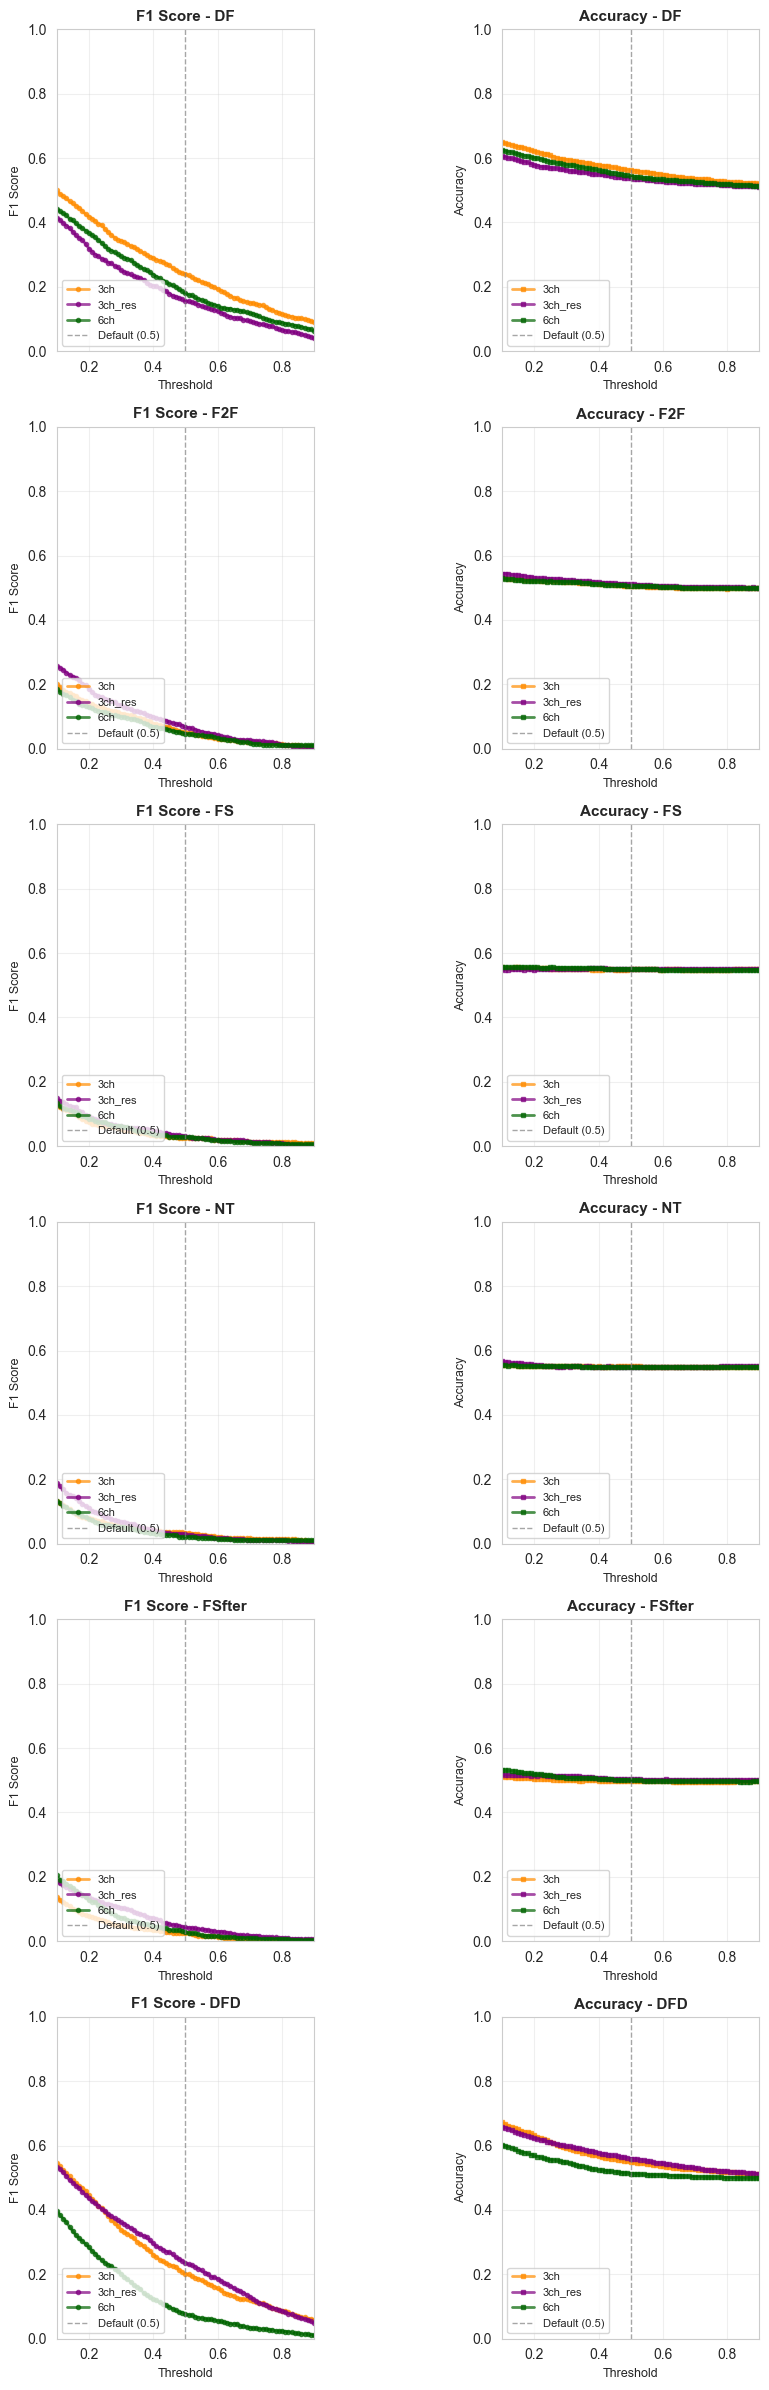

In [9]:
# Plot F1 Score curves for each dataset
from sklearn.metrics import f1_score

fig, axes = plt.subplots(6, 2, figsize=(10, 24))

for row_idx, dataset in enumerate(datasets):
    # F1 Score (left column)
    ax_f1 = axes[row_idx, 0]
    thresholds_range = np.linspace(0.1, 0.9, 81)
    f1_scores_by_model = {model: [] for model in models}
    
    for model in models:
        for threshold in thresholds_range:
            df_data = data_dict[model][dataset]
            y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
            y_scores = df_data['Synthesis_Probability'].values
            y_pred = (y_scores >= threshold).astype(int)
            f1 = f1_score(y_true, y_pred)
            f1_scores_by_model[model].append(f1)
        
        ax_f1.plot(thresholds_range, f1_scores_by_model[model], color=colors[model], lw=2,
                   label=f'{model}', marker='o', markersize=3, alpha=0.7)
    
    ax_f1.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Default (0.5)')
    ax_f1.set_xlim([0.1, 0.9])
    ax_f1.set_ylim([0, 1.0])
    ax_f1.set_xlabel('Threshold', fontsize=9)
    ax_f1.set_ylabel('F1 Score', fontsize=9)
    ax_f1.set_title(f'F1 Score - {dataset}', fontsize=11, fontweight='bold')
    ax_f1.legend(fontsize=8, loc='lower left')
    ax_f1.grid(True, alpha=0.3)
    ax_f1.set_aspect('equal', adjustable='box')
    
    # Accuracy (right column)
    ax_acc = axes[row_idx, 1]
    accuracy_by_model = {model: [] for model in models}
    
    for model in models:
        for threshold in thresholds_range:
            df_data = data_dict[model][dataset]
            y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
            y_scores = df_data['Synthesis_Probability'].values
            y_pred = (y_scores >= threshold).astype(int)
            from sklearn.metrics import accuracy_score
            acc = accuracy_score(y_true, y_pred)
            accuracy_by_model[model].append(acc)
        
        ax_acc.plot(thresholds_range, accuracy_by_model[model], color=colors[model], lw=2,
                    label=f'{model}', marker='s', markersize=3, alpha=0.7)
    
    ax_acc.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Default (0.5)')
    ax_acc.set_xlim([0.1, 0.9])
    ax_acc.set_ylim([0, 1.0])
    ax_acc.set_xlabel('Threshold', fontsize=9)
    ax_acc.set_ylabel('Accuracy', fontsize=9)
    ax_acc.set_title(f'Accuracy - {dataset}', fontsize=11, fontweight='bold')
    ax_acc.legend(fontsize=8, loc='lower left')
    ax_acc.grid(True, alpha=0.3)
    ax_acc.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

In [10]:
# Display F1 Score and other metrics at threshold 0.5
from sklearn.metrics import f1_score, accuracy_score

print("\n" + "="*150)
print("METRICS AT DEFAULT THRESHOLD (0.5)")
print("="*150)

for model in models:
    print(f"\n{model.upper()}")
    print("-"*150)
    print(f"{'Dataset':<10} {'F1 Score':<12} {'Accuracy':<12} {'Precision':<12} {'Sensitivity':<12} {'Specificity':<12} {'TP':<6} {'TN':<6} {'FP':<6} {'FN':<6}")
    print("-"*150)
    
    for dataset in datasets:
        df_data = data_dict[model][dataset]
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        y_pred = (y_scores >= 0.5).astype(int)
        
        # Calculate metrics
        f1 = f1_score(y_true, y_pred)
        accuracy = accuracy_score(y_true, y_pred)
        
        from sklearn.metrics import precision_score, recall_score
        precision = precision_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)  # True Positive Rate
        
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        print(f"{dataset:<10} {f1:<12.4f} {accuracy:<12.4f} {precision:<12.4f} {sensitivity:<12.4f} {specificity:<12.4f} {tp:<6} {tn:<6} {fp:<6} {fn:<6}")

print("\n" + "="*150)

# Create comprehensive table
print("\n" + "="*200)
print("COMPREHENSIVE TABLE - ALL MODELS AND DATASETS (Threshold 0.5)")
print("="*200)

all_metrics = []
for model in models:
    for dataset in datasets:
        df_data = data_dict[model][dataset]
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        y_pred = (y_scores >= 0.5).astype(int)
        
        f1 = f1_score(y_true, y_pred)
        accuracy = accuracy_score(y_true, y_pred)
        precision = precision_score(y_true, y_pred)
        sensitivity = recall_score(y_true, y_pred)
        
        cm = confusion_matrix(y_true, y_pred)
        tn, fp, fn, tp = cm.ravel()
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        
        all_metrics.append({
            'Model': model,
            'Dataset': dataset,
            'F1_Score': f1,
            'Accuracy': accuracy,
            'Precision': precision,
            'Sensitivity': sensitivity,
            'Specificity': specificity,
            'TP': tp,
            'TN': tn,
            'FP': fp,
            'FN': fn
        })

metrics_table = pd.DataFrame(all_metrics)
print(metrics_table.to_string(index=False))
print("="*200)


METRICS AT DEFAULT THRESHOLD (0.5)

3CH
------------------------------------------------------------------------------------------------------------------------------------------------------
Dataset    F1 Score     Accuracy     Precision    Sensitivity  Specificity  TP     TN     FP     FN    
------------------------------------------------------------------------------------------------------------------------------------------------------
DF         0.2390       0.5625       0.9045       0.1377       0.9855       341    2452   36     2136  
F2F        0.0510       0.5061       0.6471       0.0265       0.9855       66     2452   36     2421  
FS         0.0259       0.5491       0.4154       0.0133       0.9847       27     2450   38     1996  
NT         0.0343       0.5513       0.5000       0.0178       0.9855       36     2452   36     1989  
FSfter     0.0258       0.4991       0.4583       0.0133       0.9843       33     2449   39     2452  
DFD        0.2012       0.5488   

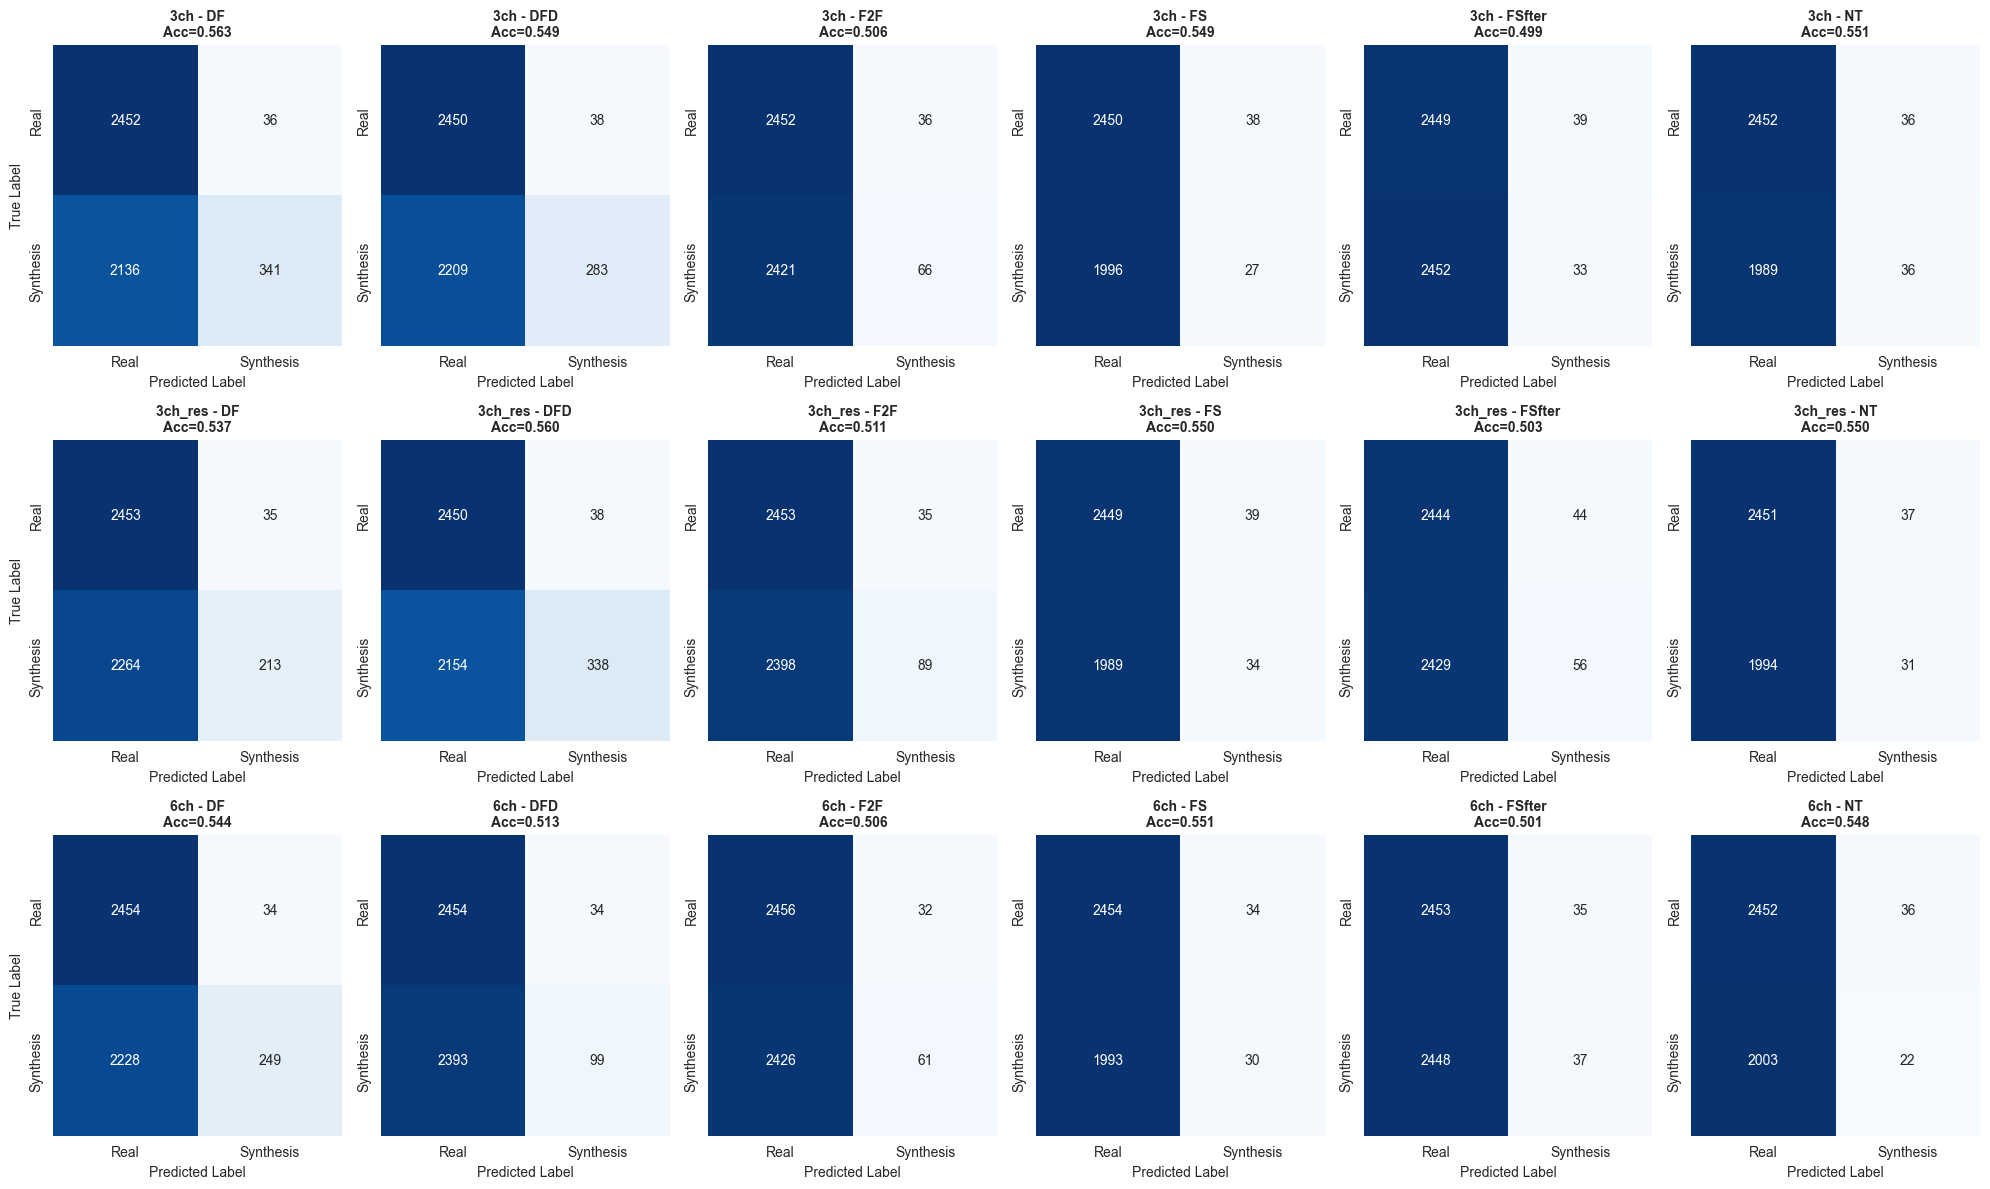

In [13]:
# Plot Confusion Matrices for each model-dataset combination
fig, axes = plt.subplots(3, 6, figsize=(20, 12))

for row_idx, model in enumerate(models):
    for col_idx, dataset in enumerate(datasets):
        cm = metrics_dict[model][dataset]['cm']
        
        # Normalize confusion matrix for better visualization
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_normalized, annot=cm, fmt='d', cmap='Blues', cbar=False,
                    ax=axes[row_idx, col_idx], 
                    xticklabels=['Real', 'Synthesis'],
                    yticklabels=['Real', 'Synthesis'],
                    vmin=0, vmax=1)
        
        accuracy = metrics_dict[model][dataset]['accuracy']
        axes[row_idx, col_idx].set_title(f'{model} - {dataset}\nAcc={accuracy:.3f}', 
                                         fontsize=10, fontweight='bold')
        axes[row_idx, col_idx].set_ylabel('True Label' if col_idx == 0 else '')
        axes[row_idx, col_idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

In [14]:
# Detailed Confusion Matrix Table
print("\n" + "="*120)
print("DETAILED CONFUSION MATRIX INFORMATION")
print("="*120)

for model in models:
    print(f"\n{'='*110}")
    print(f"MODEL: {model.upper()}")
    print(f"{'='*110}")
    
    cm_data = []
    for dataset in datasets:
        m = metrics_dict[model][dataset]
        cm_data.append({
            'Dataset': dataset,
            'TP': m['tp'],
            'TN': m['tn'],
            'FP': m['fp'],
            'FN': m['fn'],
            'Sensitivity': f"{m['sensitivity']:.4f}",
            'Specificity': f"{m['specificity']:.4f}",
            'Accuracy': f"{m['accuracy']:.4f}"
        })
    
    cm_df = pd.DataFrame(cm_data)
    print(cm_df.to_string(index=False))

print("\n" + "="*120)


DETAILED CONFUSION MATRIX INFORMATION

MODEL: 3CH
Dataset  TP   TN  FP   FN Sensitivity Specificity Accuracy
     DF 341 2452  36 2136      0.1377      0.9855   0.5625
    DFD 283 2450  38 2209      0.1136      0.9847   0.5488
    F2F  66 2452  36 2421      0.0265      0.9855   0.5061
     FS  27 2450  38 1996      0.0133      0.9847   0.5491
 FSfter  33 2449  39 2452      0.0133      0.9843   0.4991
     NT  36 2452  36 1989      0.0178      0.9855   0.5513

MODEL: 3CH_RES
Dataset  TP   TN  FP   FN Sensitivity Specificity Accuracy
     DF 213 2453  35 2264      0.0860      0.9859   0.5370
    DFD 338 2450  38 2154      0.1356      0.9847   0.5598
    F2F  89 2453  35 2398      0.0358      0.9859   0.5110
     FS  34 2449  39 1989      0.0168      0.9843   0.5504
 FSfter  56 2444  44 2429      0.0225      0.9823   0.5027
     NT  31 2451  37 1994      0.0153      0.9851   0.5500

MODEL: 6CH
Dataset  TP   TN  FP   FN Sensitivity Specificity Accuracy
     DF 249 2454  34 2228      0.100

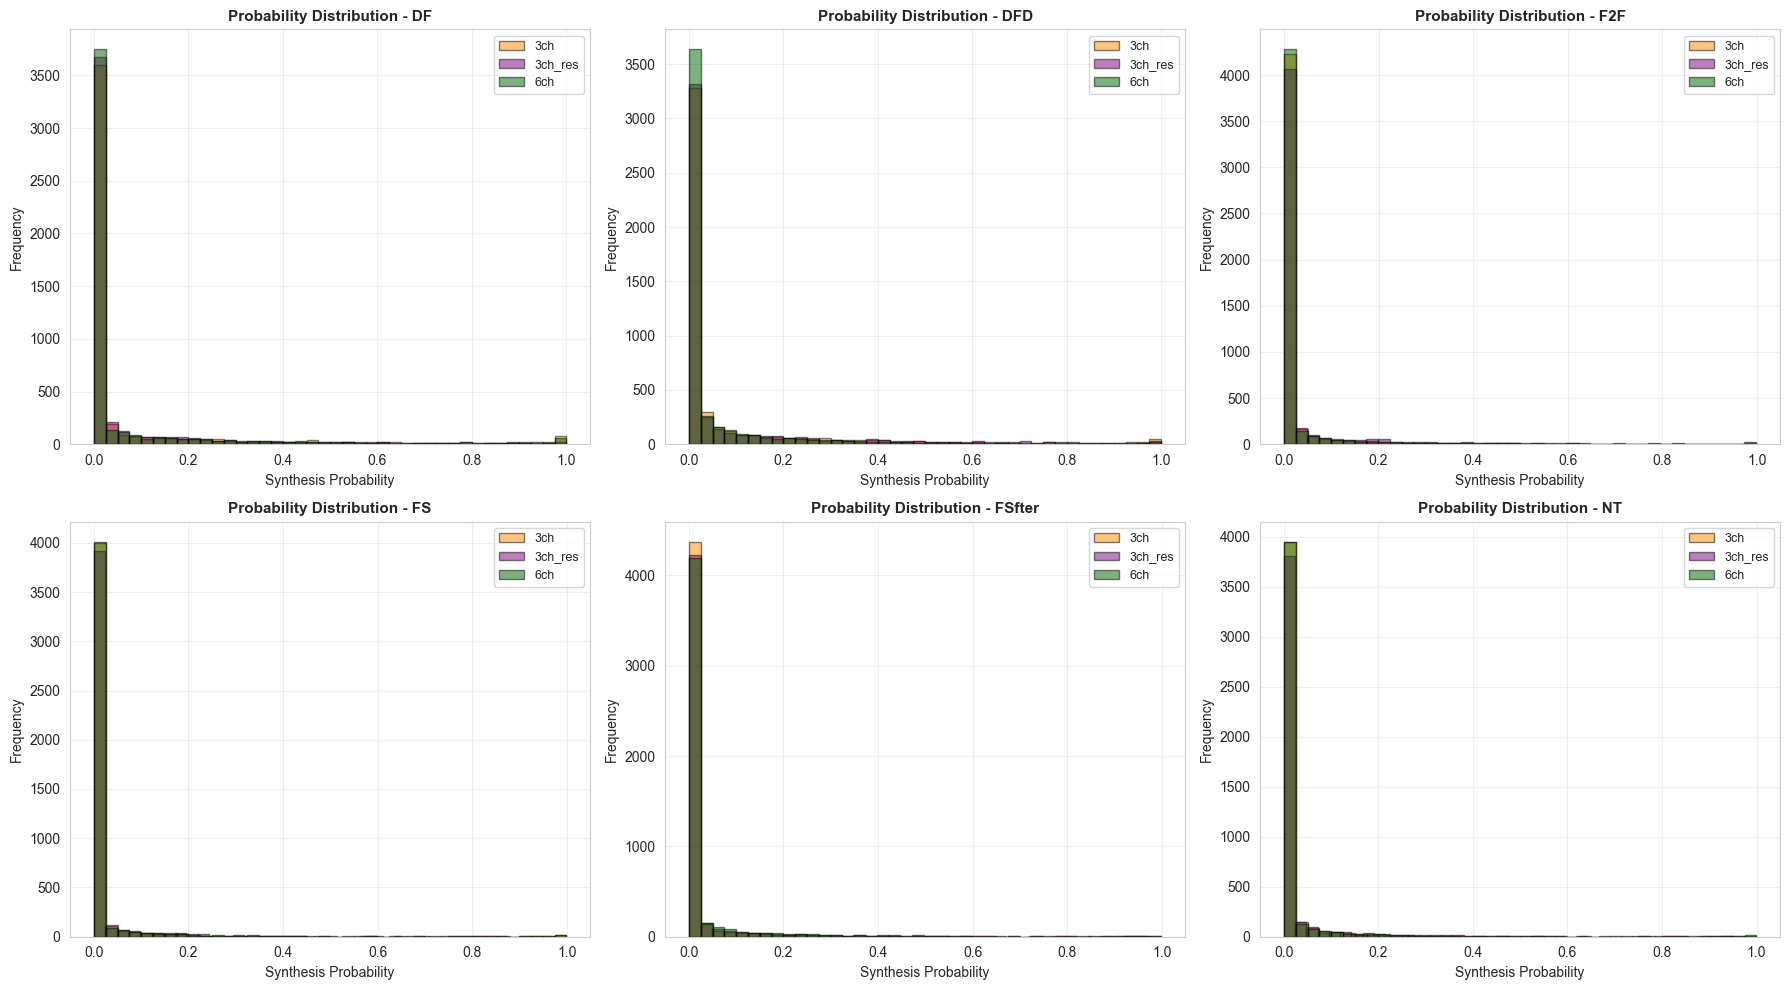

In [8]:
# Plot probability distributions for each dataset
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for col_idx, dataset in enumerate(datasets):
    # Create overlaid histograms for all models
    for model in models:
        df_data = data_dict[model][dataset]
        synth_prob = df_data['Synthesis_Probability'].values
        
        axes[col_idx].hist(synth_prob, bins=40, alpha=0.5, label=model, color=colors[model], edgecolor='black')
    
    axes[col_idx].set_xlabel('Synthesis Probability', fontsize=10)
    axes[col_idx].set_ylabel('Frequency', fontsize=10)
    axes[col_idx].set_title(f'Probability Distribution - {dataset}', fontsize=11, fontweight='bold')
    axes[col_idx].legend(fontsize=9)
    axes[col_idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

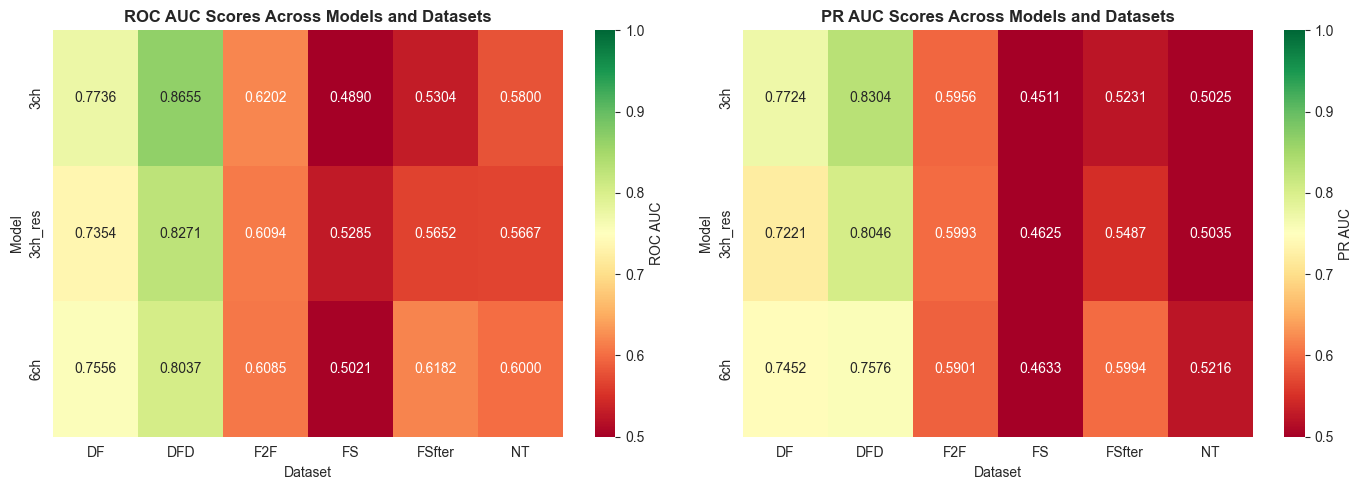

In [9]:
# Plot performance heatmaps (ROC AUC by model and dataset)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prepare data for heatmaps
roc_auc_matrix = np.zeros((len(models), len(datasets)))
pr_auc_matrix = np.zeros((len(models), len(datasets)))

for i, model in enumerate(models):
    for j, dataset in enumerate(datasets):
        roc_auc_matrix[i, j] = metrics_dict[model][dataset]['roc_auc']
        pr_auc_matrix[i, j] = metrics_dict[model][dataset]['pr_auc']

# ROC AUC Heatmap
sns.heatmap(roc_auc_matrix, annot=True, fmt='.4f', cmap='RdYlGn', 
            xticklabels=datasets, yticklabels=models, ax=axes[0],
            cbar_kws={'label': 'ROC AUC'}, vmin=0.5, vmax=1.0)
axes[0].set_title('ROC AUC Scores Across Models and Datasets', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Model')

# PR AUC Heatmap
sns.heatmap(pr_auc_matrix, annot=True, fmt='.4f', cmap='RdYlGn',
            xticklabels=datasets, yticklabels=models, ax=axes[1],
            cbar_kws={'label': 'PR AUC'}, vmin=0.5, vmax=1.0)
axes[1].set_title('PR AUC Scores Across Models and Datasets', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

In [11]:
# Statistical Summary
print("\n" + "="*120)
print("STATISTICAL SUMMARY")
print("="*120)

print("\nBest Performance by Metric:")
print("-"*120)

# Best ROC AUC
best_roc_model, best_roc_dataset = None, None
best_roc_score = 0
for model in models:
    for dataset in datasets:
        if metrics_dict[model][dataset]['roc_auc'] > best_roc_score:
            best_roc_score = metrics_dict[model][dataset]['roc_auc']
            best_roc_model, best_roc_dataset = model, dataset

# Best PR AUC
best_pr_model, best_pr_dataset = None, None
best_pr_score = 0
for model in models:
    for dataset in datasets:
        if metrics_dict[model][dataset]['pr_auc'] > best_pr_score:
            best_pr_score = metrics_dict[model][dataset]['pr_auc']
            best_pr_model, best_pr_dataset = model, dataset

# Best Accuracy
best_acc_model, best_acc_dataset = None, None
best_acc_score = 0
for model in models:
    for dataset in datasets:
        if metrics_dict[model][dataset]['accuracy'] > best_acc_score:
            best_acc_score = metrics_dict[model][dataset]['accuracy']
            best_acc_model, best_acc_dataset = model, dataset

print(f"Best ROC AUC: {best_roc_model} on {best_roc_dataset} = {best_roc_score:.4f}")
print(f"Best PR AUC: {best_pr_model} on {best_pr_dataset} = {best_pr_score:.4f}")
print(f"Best Accuracy: {best_acc_model} on {best_acc_dataset} = {best_acc_score:.4f}")

print("\nAverage Performance by Model:")
print("-"*120)
for model in models:
    avg_roc = np.mean([metrics_dict[model][ds]['roc_auc'] for ds in datasets])
    avg_pr = np.mean([metrics_dict[model][ds]['pr_auc'] for ds in datasets])
    avg_acc = np.mean([metrics_dict[model][ds]['accuracy'] for ds in datasets])
    print(f"{model}: ROC AUC={avg_roc:.4f} | PR AUC={avg_pr:.4f} | Accuracy={avg_acc:.4f}")

print("\nAverage Performance by Dataset:")
print("-"*120)
for dataset in datasets:
    avg_roc = np.mean([metrics_dict[model][dataset]['roc_auc'] for model in models])
    avg_pr = np.mean([metrics_dict[model][dataset]['pr_auc'] for model in models])
    avg_acc = np.mean([metrics_dict[model][dataset]['accuracy'] for model in models])
    print(f"{dataset}: ROC AUC={avg_roc:.4f} | PR AUC={avg_pr:.4f} | Accuracy={avg_acc:.4f}")

print("\n" + "="*120)


STATISTICAL SUMMARY

Best Performance by Metric:
------------------------------------------------------------------------------------------------------------------------
Best ROC AUC: 3ch on DFD = 0.8655
Best PR AUC: 3ch on DFD = 0.8304
Best Accuracy: 3ch on DF = 0.5625

Average Performance by Model:
------------------------------------------------------------------------------------------------------------------------
3ch: ROC AUC=0.6431 | PR AUC=0.6125 | Accuracy=0.5362
3ch_res: ROC AUC=0.6387 | PR AUC=0.6068 | Accuracy=0.5351
6ch: ROC AUC=0.6480 | PR AUC=0.6129 | Accuracy=0.5271

Average Performance by Dataset:
------------------------------------------------------------------------------------------------------------------------
DF: ROC AUC=0.7549 | PR AUC=0.7465 | Accuracy=0.5480
DFD: ROC AUC=0.8321 | PR AUC=0.7975 | Accuracy=0.5404
F2F: ROC AUC=0.6127 | PR AUC=0.5950 | Accuracy=0.5077
FS: ROC AUC=0.5065 | PR AUC=0.4590 | Accuracy=0.5501
FSfter: ROC AUC=0.5713 | PR AUC=0.5571 | A

In [24]:
# Threshold Optimization
from sklearn.metrics import f1_score, matthews_corrcoef

# Calculate optimal thresholds for each model and dataset
optimal_thresholds = {}
threshold_metrics = {}

thresholds_range = np.linspace(0.1, 0.9, 81)  # 0.1 to 0.9 in steps of 0.01

for model in models:
    optimal_thresholds[model] = {}
    threshold_metrics[model] = {}
    
    for dataset in datasets:
        df_data = data_dict[model][dataset]
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        
        best_f1 = 0
        best_youden = 0
        best_accuracy = 0
        
        threshold_f1 = 0.5
        threshold_youden = 0.5
        threshold_accuracy = 0.5
        
        metrics_by_threshold = []
        
        for threshold in thresholds_range:
            y_pred = (y_scores >= threshold).astype(int)
            
            cm = confusion_matrix(y_true, y_pred)
            tn, fp, fn, tp = cm.ravel()
            
            # Calculate metrics
            f1 = f1_score(y_true, y_pred)
            accuracy = (tp + tn) / (tp + tn + fp + fn)
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden = sensitivity + specificity - 1
            
            metrics_by_threshold.append({
                'threshold': threshold,
                'f1': f1,
                'accuracy': accuracy,
                'youden': youden,
                'sensitivity': sensitivity,
                'specificity': specificity
            })
            
            # Find best thresholds
            if f1 > best_f1:
                best_f1 = f1
                threshold_f1 = threshold
            
            if youden > best_youden:
                best_youden = youden
                threshold_youden = threshold
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                threshold_accuracy = threshold
        
        optimal_thresholds[model][dataset] = {
            'f1': threshold_f1,
            'youden': threshold_youden,
            'accuracy': threshold_accuracy
        }
        
        threshold_metrics[model][dataset] = pd.DataFrame(metrics_by_threshold)

print("Threshold optimization completed")
print(f"Threshold range: {thresholds_range[0]:.2f} to {thresholds_range[-1]:.2f}")

Threshold optimization completed
Threshold range: 0.10 to 0.90


In [25]:
# Display optimal thresholds and comparison with default threshold (0.5)
print("\n" + "="*140)
print("OPTIMAL THRESHOLD ANALYSIS")
print("="*140)

for model in models:
    print(f"\n{'='*130}")
    print(f"MODEL: {model.upper()}")
    print(f"{'='*130}")
    
    threshold_data = []
    for dataset in datasets:
        df_data = data_dict[model][dataset]
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        
        # Metrics at default threshold (0.5)
        y_pred_default = (y_scores >= 0.5).astype(int)
        cm_default = confusion_matrix(y_true, y_pred_default)
        tn, fp, fn, tp = cm_default.ravel()
        f1_default = f1_score(y_true, y_pred_default)
        acc_default = (tp + tn) / (tp + tn + fp + fn)
        sens_default = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_default = tn / (tn + fp) if (tn + fp) > 0 else 0
        youden_default = sens_default + spec_default - 1
        
        # Metrics at F1-optimal threshold
        threshold_f1 = optimal_thresholds[model][dataset]['f1']
        y_pred_f1 = (y_scores >= threshold_f1).astype(int)
        f1_f1 = f1_score(y_true, y_pred_f1)
        cm_f1 = confusion_matrix(y_true, y_pred_f1)
        tn, fp, fn, tp = cm_f1.ravel()
        acc_f1 = (tp + tn) / (tp + tn + fp + fn)
        sens_f1 = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_f1 = tn / (tn + fp) if (tn + fp) > 0 else 0
        youden_f1 = sens_f1 + spec_f1 - 1
        
        # Metrics at Youden-optimal threshold
        threshold_youden = optimal_thresholds[model][dataset]['youden']
        y_pred_youden = (y_scores >= threshold_youden).astype(int)
        cm_youden = confusion_matrix(y_true, y_pred_youden)
        tn, fp, fn, tp = cm_youden.ravel()
        f1_youden = f1_score(y_true, y_pred_youden)
        acc_youden = (tp + tn) / (tp + tn + fp + fn)
        sens_youden = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_youden = tn / (tn + fp) if (tn + fp) > 0 else 0
        youden_youden = sens_youden + spec_youden - 1
        
        threshold_data.append({
            'Dataset': dataset,
            'Default_Threshold': 0.5,
            'Default_F1': f1_default,
            'Default_Accuracy': acc_default,
            'Default_Youden': youden_default,
            'F1_Optimal_Threshold': f"{threshold_f1:.3f}",
            'F1_Optimal_F1': f1_f1,
            'Youden_Optimal_Threshold': f"{threshold_youden:.3f}",
            'Youden_Optimal_Youden': youden_youden
        })
    
    threshold_df = pd.DataFrame(threshold_data)
    print(threshold_df[['Dataset', 'Default_F1', 'F1_Optimal_F1', 'Default_Youden', 'Youden_Optimal_Youden']].to_string(index=False))
    
    # Display confusion matrices for each dataset
    print(f"\n\n{'─'*130}")
    print(f"CONFUSION MATRICES FOR {model.upper()}")
    print(f"{'─'*130}")
    
    for dataset in datasets:
        df_data = data_dict[model][dataset]
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        
        threshold_f1 = optimal_thresholds[model][dataset]['f1']
        threshold_youden = optimal_thresholds[model][dataset]['youden']
        
        # CM at default threshold (0.5)
        y_pred_default = (y_scores >= 0.5).astype(int)
        cm_default = confusion_matrix(y_true, y_pred_default)
        tn, fp, fn, tp = cm_default.ravel()
        
        # CM at F1-optimal threshold
        y_pred_f1 = (y_scores >= threshold_f1).astype(int)
        cm_f1 = confusion_matrix(y_true, y_pred_f1)
        tn_f1, fp_f1, fn_f1, tp_f1 = cm_f1.ravel()
        
        # CM at Youden-optimal threshold
        y_pred_youden = (y_scores >= threshold_youden).astype(int)
        cm_youden = confusion_matrix(y_true, y_pred_youden)
        tn_y, fp_y, fn_y, tp_y = cm_youden.ravel()
        
        print(f"\n{dataset}:")
        print(f"  Default (0.500):        TP={tp:4d} | FN={fn:4d} | FP={fp:4d} | TN={tn:4d}")
        print(f"  F1-Optimal ({threshold_f1:.3f}):  TP={tp_f1:4d} | FN={fn_f1:4d} | FP={fp_f1:4d} | TN={tn_f1:4d}")
        print(f"  Youden-Optimal ({threshold_youden:.3f}): TP={tp_y:4d} | FN={fn_y:4d} | FP={fp_y:4d} | TN={tn_y:4d}")

print("\n" + "="*140)


OPTIMAL THRESHOLD ANALYSIS

MODEL: 3CH
Dataset  Default_F1  F1_Optimal_F1  Default_Youden  Youden_Optimal_Youden
     DF    0.238963       0.499713        0.123197               0.296971
    DFD    0.201209       0.547322        0.098290               0.345425
    F2F    0.050985       0.200206        0.012069               0.061944
     FS    0.025862       0.136797       -0.001927               0.026253
 FSfter    0.025811       0.137220       -0.002396               0.023406
     NT    0.034335       0.131317        0.003308               0.020066


──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
CONFUSION MATRICES FOR 3CH
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

DF:
  Default (0.500):        TP= 341 | FN=2136 | FP=  36 | TN=2452
  F1-Optimal (0.100):  TP= 870 | FN=1607 | FP= 135 | TN=2353
  Youden-Optimal (0.1

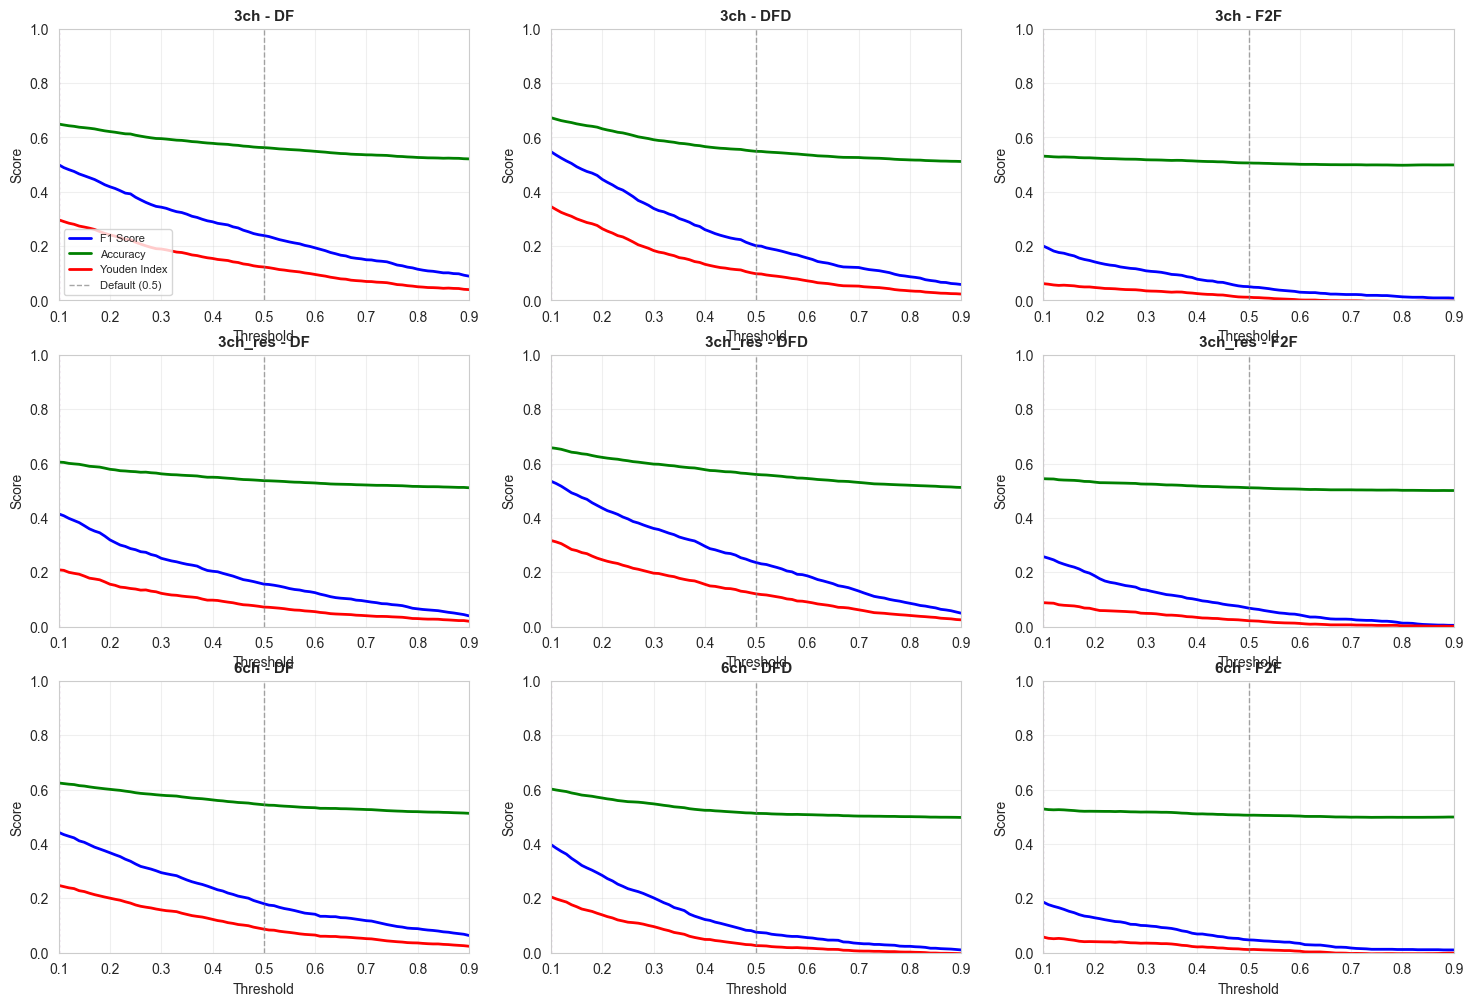

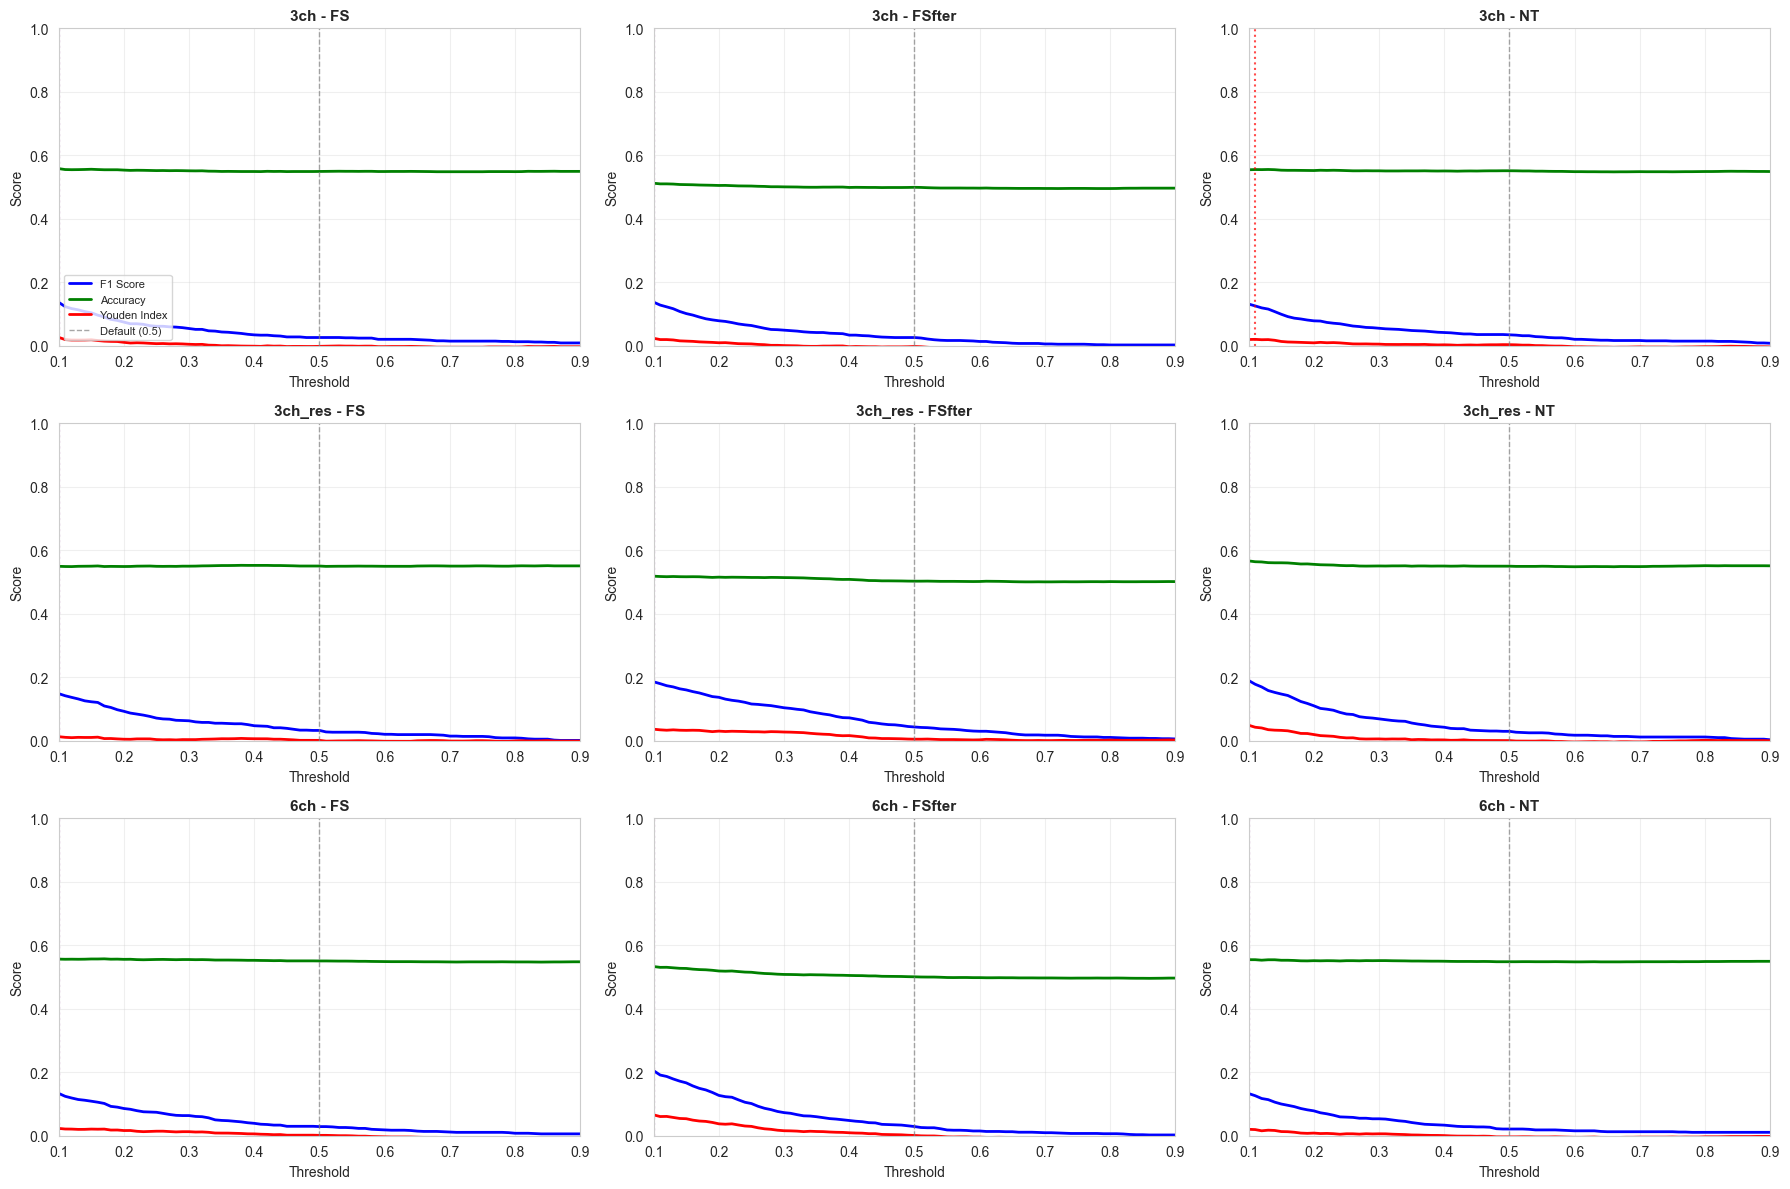

In [23]:
# Plot threshold optimization curves for each model
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, model in enumerate(models):
    for col_idx, dataset in enumerate(datasets[:3]):  # First row: DF, DFD, F2F
        metrics_df = threshold_metrics[model][dataset]
        
        ax = axes[row_idx, col_idx]
        ax.plot(metrics_df['threshold'], metrics_df['f1'], label='F1 Score', linewidth=2, color='blue')
        ax.plot(metrics_df['threshold'], metrics_df['accuracy'], label='Accuracy', linewidth=2, color='green')
        ax.plot(metrics_df['threshold'], metrics_df['youden'], label='Youden Index', linewidth=2, color='red')
        
        # Mark optimal thresholds
        threshold_f1 = optimal_thresholds[model][dataset]['f1']
        threshold_youden = optimal_thresholds[model][dataset]['youden']
        
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Default (0.5)')
        ax.axvline(threshold_f1, color='blue', linestyle=':', linewidth=1.5, alpha=0.7)
        ax.axvline(threshold_youden, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Threshold', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_title(f'{model} - {dataset}', fontsize=11, fontweight='bold')
        ax.set_xlim([0.1, 0.9])
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8, loc='lower left')

# Second row: FS, FSfter, NT
fig2, axes2 = plt.subplots(3, 3, figsize=(18, 12))

for row_idx, model in enumerate(models):
    for col_idx, dataset in enumerate(datasets[3:]):  # Second row: FS, FSfter, NT
        metrics_df = threshold_metrics[model][dataset]
        
        ax = axes2[row_idx, col_idx]
        ax.plot(metrics_df['threshold'], metrics_df['f1'], label='F1 Score', linewidth=2, color='blue')
        ax.plot(metrics_df['threshold'], metrics_df['accuracy'], label='Accuracy', linewidth=2, color='green')
        ax.plot(metrics_df['threshold'], metrics_df['youden'], label='Youden Index', linewidth=2, color='red')
        
        # Mark optimal thresholds
        threshold_f1 = optimal_thresholds[model][dataset]['f1']
        threshold_youden = optimal_thresholds[model][dataset]['youden']
        
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='Default (0.5)')
        ax.axvline(threshold_f1, color='blue', linestyle=':', linewidth=1.5, alpha=0.7)
        ax.axvline(threshold_youden, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
        
        ax.set_xlabel('Threshold', fontsize=10)
        ax.set_ylabel('Score', fontsize=10)
        ax.set_title(f'{model} - {dataset}', fontsize=11, fontweight='bold')
        ax.set_xlim([0.1, 0.9])
        ax.set_ylim([0, 1])
        ax.grid(True, alpha=0.3)
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=8, loc='lower left')

plt.tight_layout()
plt.show()

fig2.tight_layout()
plt.show()

In [20]:
# Summary of optimal thresholds
print("\n" + "="*140)
print("OPTIMAL THRESHOLDS SUMMARY")
print("="*140)

for model in models:
    print(f"\n{model.upper()}:")
    print("-"*80)
    print(f"{'Dataset':<15} {'F1-Optimal Threshold':<20} {'Youden-Optimal Threshold':<20} {'Accuracy-Optimal Threshold':<20}")
    print("-"*80)
    
    for dataset in datasets:
        threshold_f1 = optimal_thresholds[model][dataset]['f1']
        threshold_youden = optimal_thresholds[model][dataset]['youden']
        threshold_accuracy = optimal_thresholds[model][dataset]['accuracy']
        
        print(f"{dataset:<15} {threshold_f1:<20.4f} {threshold_youden:<20.4f} {threshold_accuracy:<20.4f}")

print("\n" + "="*140)


OPTIMAL THRESHOLDS SUMMARY

3CH:
--------------------------------------------------------------------------------
Dataset         F1-Optimal Threshold Youden-Optimal Threshold Accuracy-Optimal Threshold
--------------------------------------------------------------------------------
DF              0.1000               0.1000               0.1000              
DFD             0.1000               0.1000               0.1000              
F2F             0.1000               0.1000               0.1000              
FS              0.1000               0.1000               0.1000              
FSfter          0.1000               0.1000               0.1000              
NT              0.1000               0.1100               0.1300              

3CH_RES:
--------------------------------------------------------------------------------
Dataset         F1-Optimal Threshold Youden-Optimal Threshold Accuracy-Optimal Threshold
-------------------------------------------------------------

In [21]:
# Detailed comparison: Default threshold (0.5) vs Optimal thresholds
print("\n" + "="*150)
print("DETAILED COMPARISON: DEFAULT vs OPTIMAL THRESHOLDS")
print("="*150)

comparison_data = []

for model in models:
    print(f"\n{model.upper()}")
    print("-"*150)
    
    for dataset in datasets:
        df_data = data_dict[model][dataset]
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        
        # Default threshold (0.5)
        y_pred_default = (y_scores >= 0.5).astype(int)
        cm_default = confusion_matrix(y_true, y_pred_default)
        tn, fp, fn, tp = cm_default.ravel()
        f1_default = f1_score(y_true, y_pred_default)
        acc_default = (tp + tn) / (tp + tn + fp + fn)
        sens_default = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_default = tn / (tn + fp) if (tn + fp) > 0 else 0
        youden_default = sens_default + spec_default - 1
        
        # F1-optimal threshold
        threshold_f1 = optimal_thresholds[model][dataset]['f1']
        y_pred_f1 = (y_scores >= threshold_f1).astype(int)
        cm_f1 = confusion_matrix(y_true, y_pred_f1)
        tn, fp, fn, tp = cm_f1.ravel()
        f1_f1 = f1_score(y_true, y_pred_f1)
        
        # Youden-optimal threshold
        threshold_youden = optimal_thresholds[model][dataset]['youden']
        y_pred_youden = (y_scores >= threshold_youden).astype(int)
        cm_youden = confusion_matrix(y_true, y_pred_youden)
        tn, fp, fn, tp = cm_youden.ravel()
        acc_youden = (tp + tn) / (tp + tn + fp + fn)
        sens_youden = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec_youden = tn / (tn + fp) if (tn + fp) > 0 else 0
        youden_youden = sens_youden + spec_youden - 1
        
        f1_improvement = ((f1_f1 - f1_default) / f1_default * 100) if f1_default > 0 else 0
        youden_improvement = ((youden_youden - youden_default) / abs(youden_default) * 100) if youden_default != 0 else 0
        
        print(f"\n{dataset}:")
        print(f"  Default (0.500):     F1={f1_default:.4f}, Accuracy={acc_default:.4f}, Youden={youden_default:.4f}")
        print(f"  F1-Optimal ({threshold_f1:.3f}): F1={f1_f1:.4f} (+{f1_improvement:+.2f}%)")
        print(f"  Youden-Optimal ({threshold_youden:.3f}): Youden={youden_youden:.4f}, Sens={sens_youden:.4f}, Spec={spec_youden:.4f} (+{youden_improvement:+.2f}%)")

print("\n" + "="*150)


DETAILED COMPARISON: DEFAULT vs OPTIMAL THRESHOLDS

3CH
------------------------------------------------------------------------------------------------------------------------------------------------------

DF:
  Default (0.500):     F1=0.2390, Accuracy=0.5625, Youden=0.1232
  F1-Optimal (0.100): F1=0.4997 (++109.12%)
  Youden-Optimal (0.100): Youden=0.2970, Sens=0.3512, Spec=0.9457 (++141.05%)

DFD:
  Default (0.500):     F1=0.2012, Accuracy=0.5488, Youden=0.0983
  F1-Optimal (0.100): F1=0.5473 (++172.02%)
  Youden-Optimal (0.100): Youden=0.3454, Sens=0.3957, Spec=0.9498 (++251.43%)

F2F:
  Default (0.500):     F1=0.0510, Accuracy=0.5061, Youden=0.0121
  F1-Optimal (0.100): F1=0.2002 (++292.68%)
  Youden-Optimal (0.100): Youden=0.0619, Sens=0.1174, Spec=0.9445 (++413.27%)

FS:
  Default (0.500):     F1=0.0259, Accuracy=0.5491, Youden=-0.0019
  F1-Optimal (0.100): F1=0.1368 (++428.95%)
  Youden-Optimal (0.100): Youden=0.0263, Sens=0.0781, Spec=0.9482 (++1462.52%)

FSfter:
  Default (

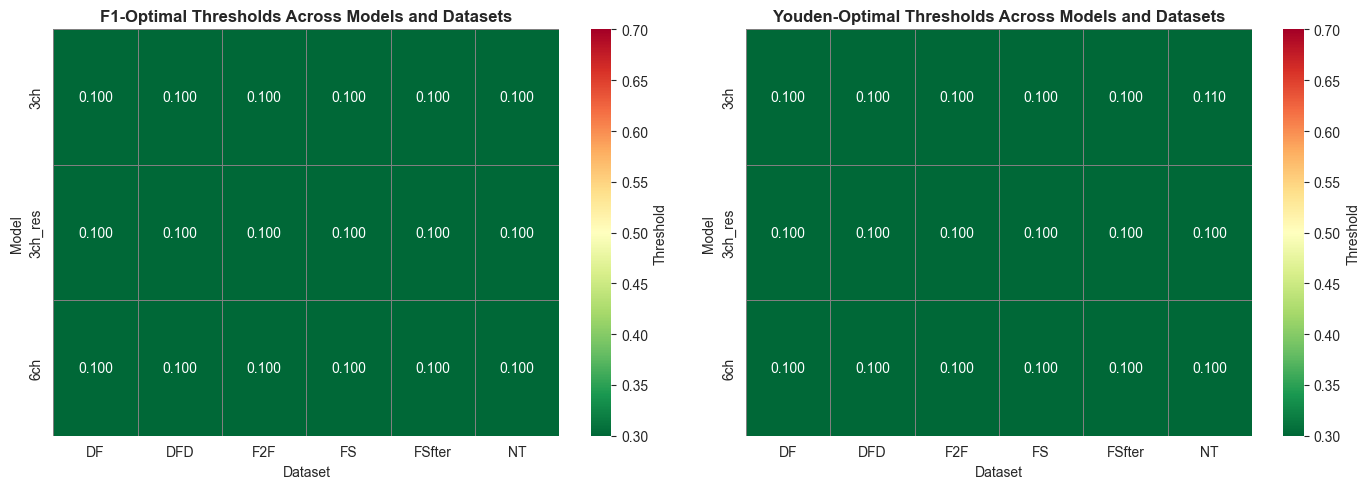

In [22]:
# Heatmap of optimal thresholds (F1-based and Youden-based)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F1-based optimal thresholds
f1_threshold_matrix = np.zeros((len(models), len(datasets)))
for i, model in enumerate(models):
    for j, dataset in enumerate(datasets):
        f1_threshold_matrix[i, j] = optimal_thresholds[model][dataset]['f1']

sns.heatmap(f1_threshold_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=datasets, yticklabels=models, ax=axes[0],
            cbar_kws={'label': 'Threshold'}, vmin=0.3, vmax=0.7,
            linewidths=0.5, linecolor='gray')
axes[0].set_title('F1-Optimal Thresholds Across Models and Datasets', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Dataset')
axes[0].set_ylabel('Model')

# Youden-based optimal thresholds
youden_threshold_matrix = np.zeros((len(models), len(datasets)))
for i, model in enumerate(models):
    for j, dataset in enumerate(datasets):
        youden_threshold_matrix[i, j] = optimal_thresholds[model][dataset]['youden']

sns.heatmap(youden_threshold_matrix, annot=True, fmt='.3f', cmap='RdYlGn_r',
            xticklabels=datasets, yticklabels=models, ax=axes[1],
            cbar_kws={'label': 'Threshold'}, vmin=0.3, vmax=0.7,
            linewidths=0.5, linecolor='gray')
axes[1].set_title('Youden-Optimal Thresholds Across Models and Datasets', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Dataset')
axes[1].set_ylabel('Model')

plt.tight_layout()
plt.show()

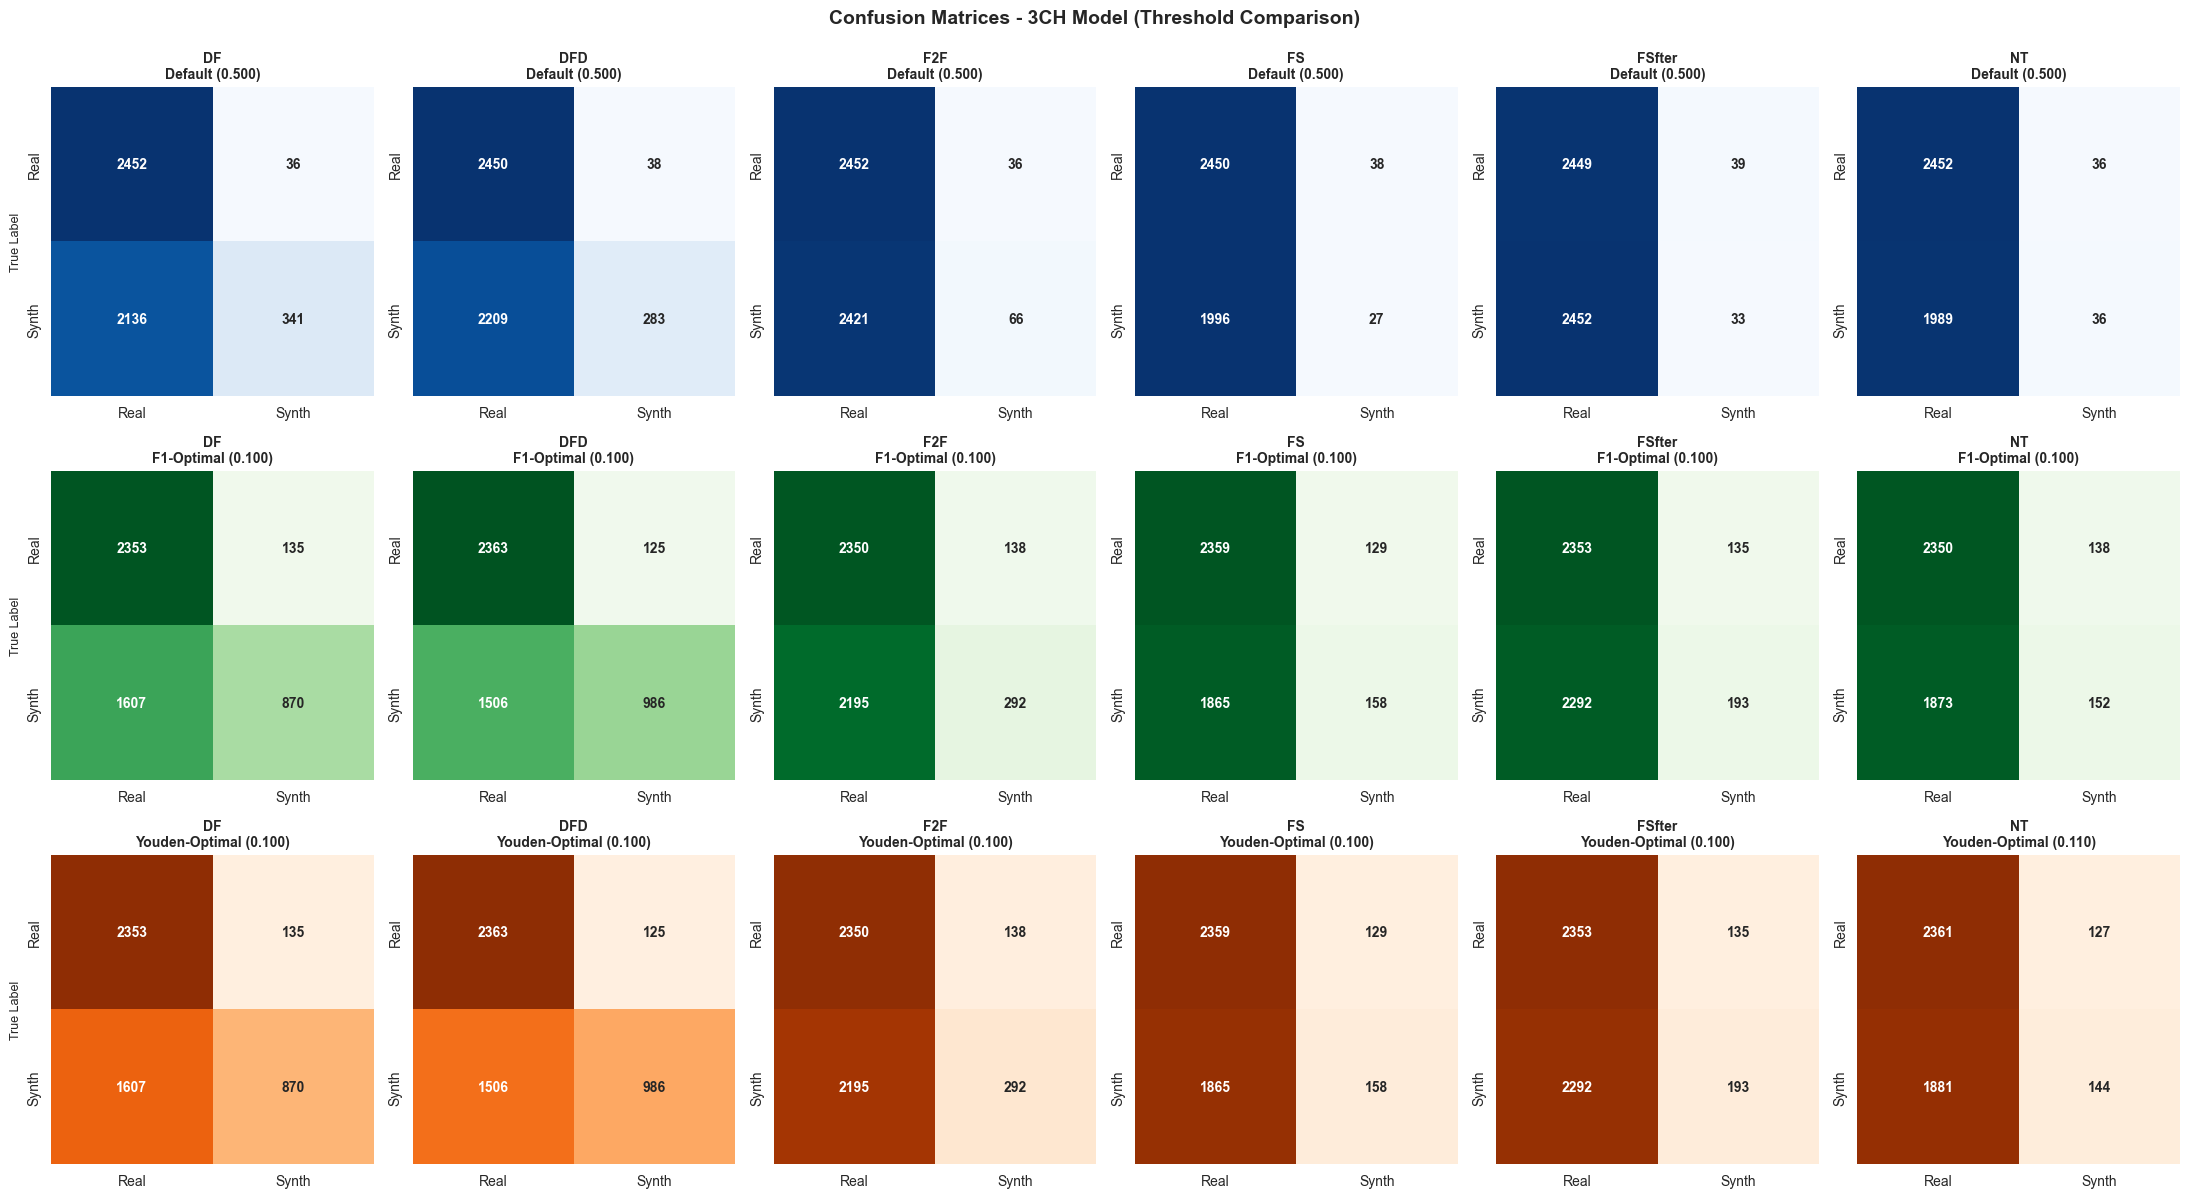

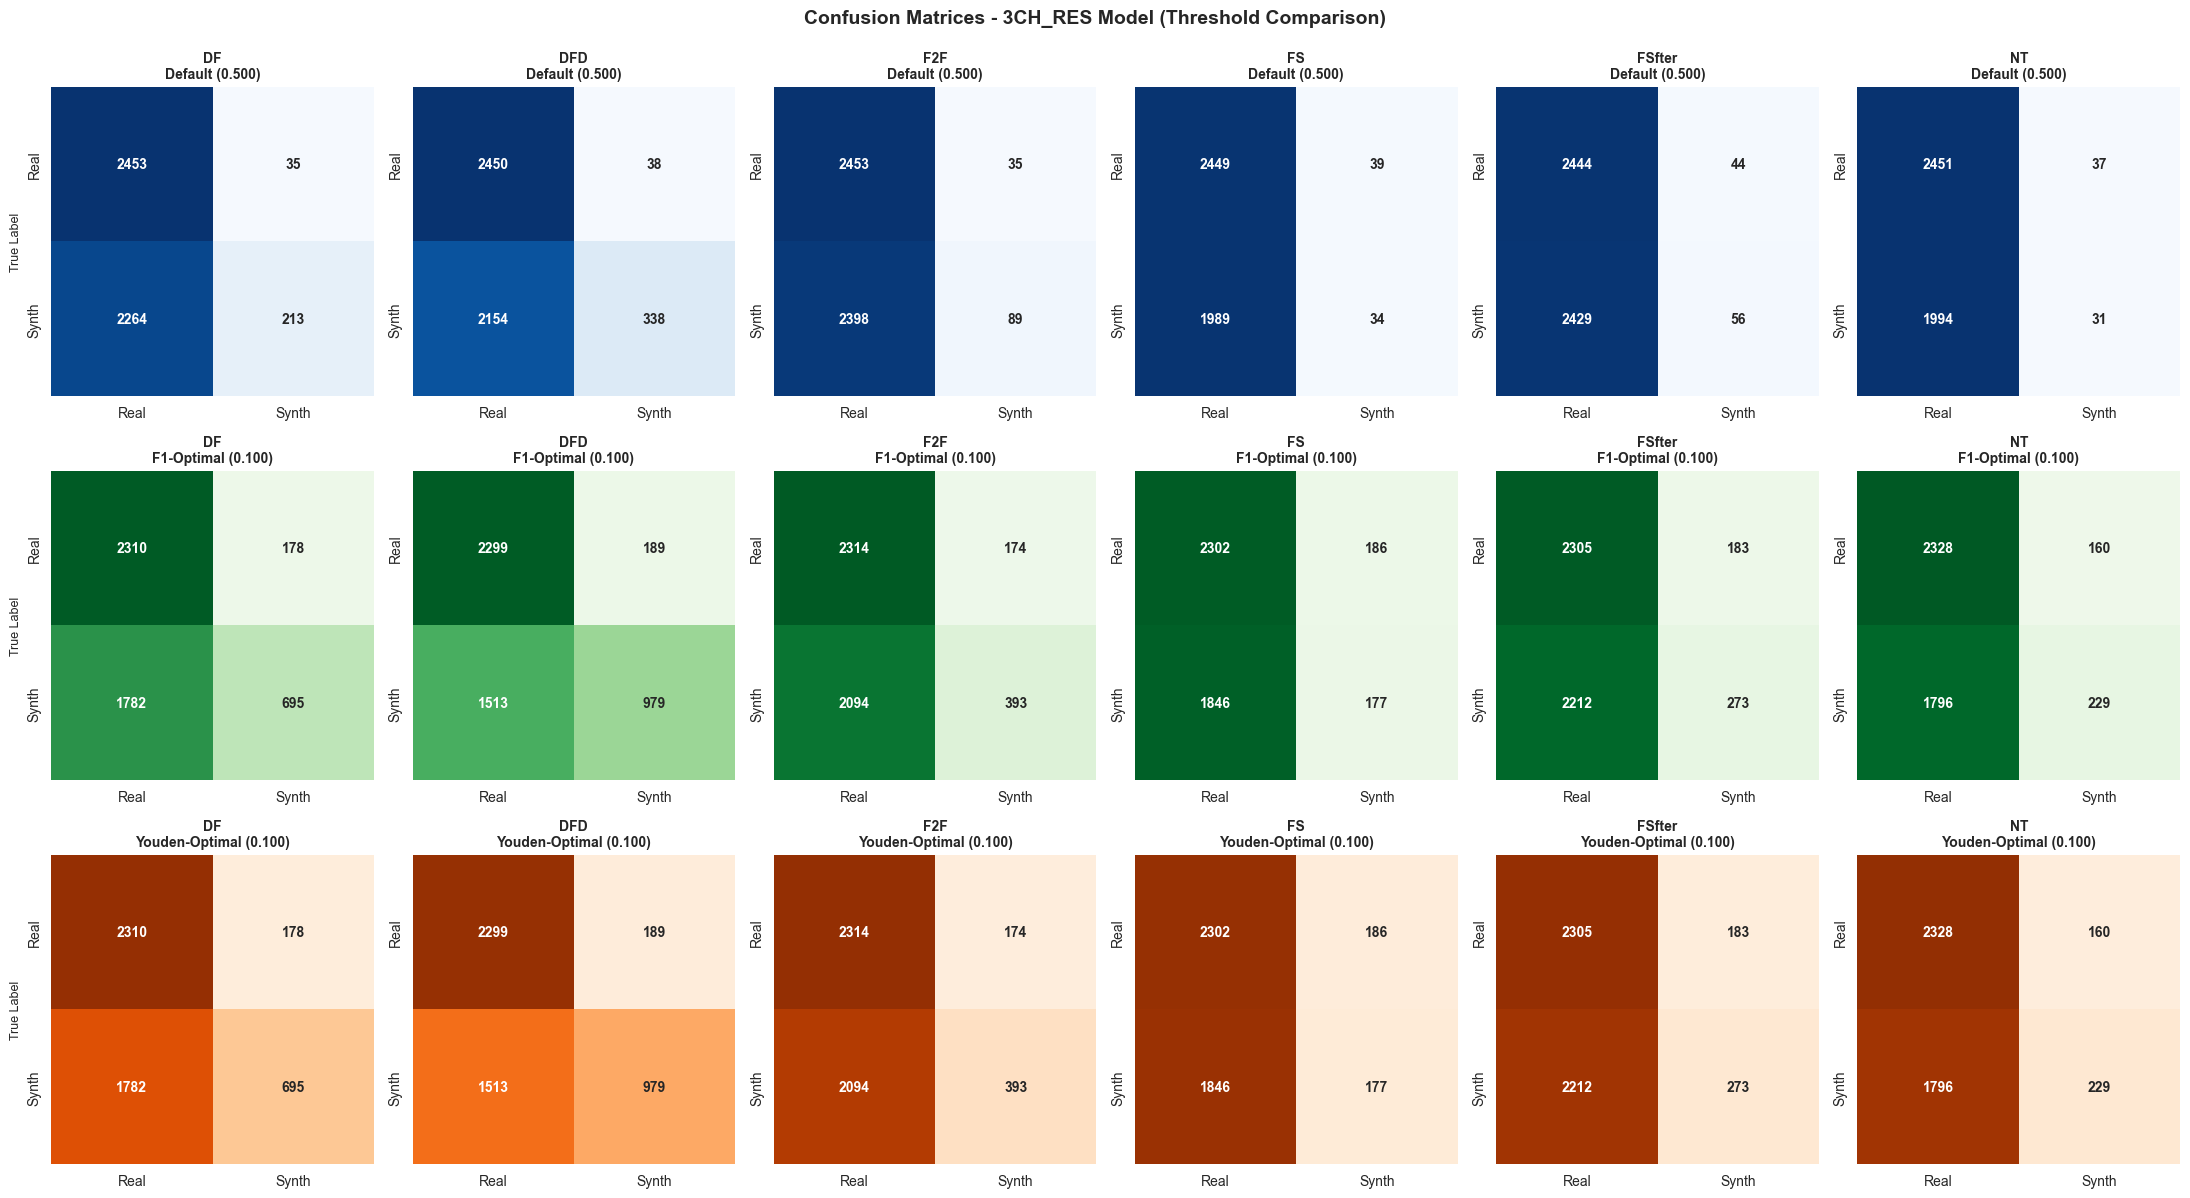

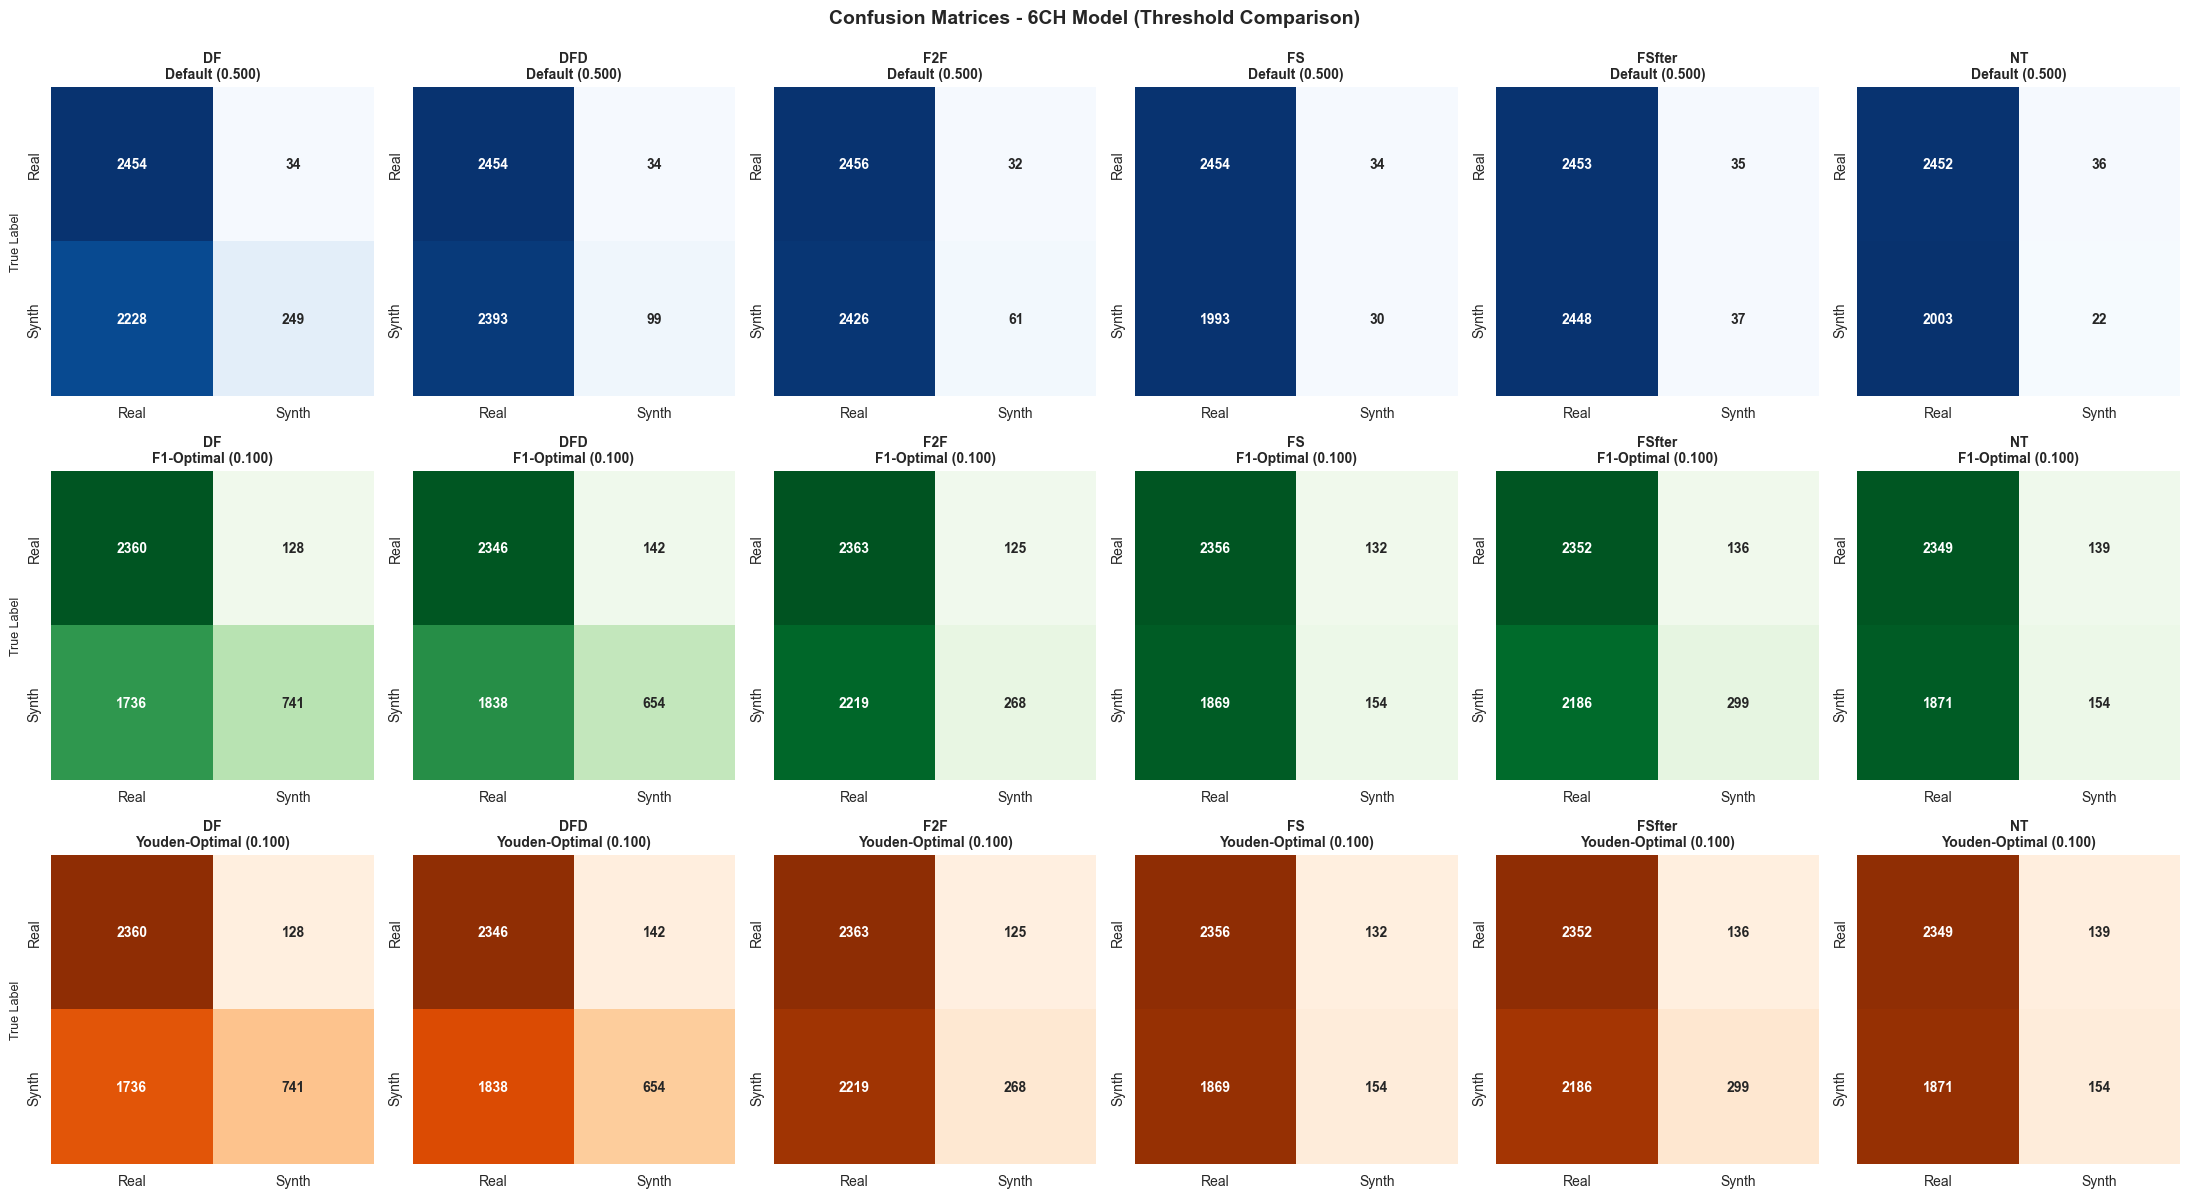

In [26]:
# Visualize confusion matrices for optimized thresholds
# For each model: show confusion matrices for all datasets at 3 threshold levels

for model in models:
    fig, axes = plt.subplots(3, 6, figsize=(22, 12))
    
    for col_idx, dataset in enumerate(datasets):
        df_data = data_dict[model][dataset]
        y_true = (df_data['True_Class'] == 'Synthesis').astype(int)
        y_scores = df_data['Synthesis_Probability'].values
        
        threshold_f1 = optimal_thresholds[model][dataset]['f1']
        threshold_youden = optimal_thresholds[model][dataset]['youden']
        
        # Row 0: Default threshold (0.5)
        y_pred_default = (y_scores >= 0.5).astype(int)
        cm_default = confusion_matrix(y_true, y_pred_default)
        cm_default_norm = cm_default.astype('float') / cm_default.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_default_norm, annot=cm_default, fmt='d', cmap='Blues', cbar=False,
                    ax=axes[0, col_idx],
                    xticklabels=['Real', 'Synth'],
                    yticklabels=['Real', 'Synth'],
                    vmin=0, vmax=1, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
        axes[0, col_idx].set_title(f'{dataset}\nDefault (0.500)', fontsize=10, fontweight='bold')
        axes[0, col_idx].set_ylabel('True Label' if col_idx == 0 else '', fontsize=9)
        
        # Row 1: F1-optimal threshold
        y_pred_f1 = (y_scores >= threshold_f1).astype(int)
        cm_f1 = confusion_matrix(y_true, y_pred_f1)
        cm_f1_norm = cm_f1.astype('float') / cm_f1.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_f1_norm, annot=cm_f1, fmt='d', cmap='Greens', cbar=False,
                    ax=axes[1, col_idx],
                    xticklabels=['Real', 'Synth'],
                    yticklabels=['Real', 'Synth'],
                    vmin=0, vmax=1, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
        axes[1, col_idx].set_title(f'{dataset}\nF1-Optimal ({threshold_f1:.3f})', fontsize=10, fontweight='bold')
        axes[1, col_idx].set_ylabel('True Label' if col_idx == 0 else '', fontsize=9)
        
        # Row 2: Youden-optimal threshold
        y_pred_youden = (y_scores >= threshold_youden).astype(int)
        cm_youden = confusion_matrix(y_true, y_pred_youden)
        cm_youden_norm = cm_youden.astype('float') / cm_youden.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_youden_norm, annot=cm_youden, fmt='d', cmap='Oranges', cbar=False,
                    ax=axes[2, col_idx],
                    xticklabels=['Real', 'Synth'],
                    yticklabels=['Real', 'Synth'],
                    vmin=0, vmax=1, annot_kws={'fontsize': 10, 'fontweight': 'bold'})
        axes[2, col_idx].set_title(f'{dataset}\nYouden-Optimal ({threshold_youden:.3f})', fontsize=10, fontweight='bold')
        axes[2, col_idx].set_ylabel('True Label' if col_idx == 0 else '', fontsize=9)
    
    fig.suptitle(f'Confusion Matrices - {model.upper()} Model (Threshold Comparison)', 
                 fontsize=14, fontweight='bold', y=0.995)
    plt.tight_layout()
    plt.show()